In [1]:
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

from SSA2 import SSAv3


%matplotlib inline

In [2]:
# f = open('80.csv','r', encoding="windows-1251")
# fo = open('82.csv','w', encoding="windows-1251")
# for line in f:
#     bits1 = line.split('+00')
#     line.replace('+00', '')
#     fo.write(''.join(bits1))
# f.close()
# fo.close()

In [3]:
# data = pd.read_csv('output1.csv',  encoding='windows-1252')
# data.reset_index(inplace=True)
# data['DateTime'] = pd.to_datetime(data['DateTime'])
# data = data.set_index('DateTime', inplace=True)

# # data.head(5)


In [4]:
# # Открытие файла и выбора заголовка, для дальнейшего выбора периода.
# data = pd.read_csv('output2.csv', parse_dates=True,  encoding='windows-1252')
# data.set_index('DateTime', inplace=True)
# data.head(5)



In [5]:
data80 = pd.read_csv('82.csv', parse_dates=True, index_col='DateTime',encoding="windows-1252") # или 106.csv
data80.head(5)

,AffinityIndex,SerialNumber,H,Tmean,WmeanH,WindDirectionH(Â°),WminH,WmaxH,WmeanV,AtmosphericPressure,RelativeHumidity,TdewPoint(Â°C),WaterVaporElasticity,AbsolutusHumidity,DensityofAir,SpeedofSoundinAir
DateTime,,,,,,,,,,,,,,,,
2019-04-10 00:05:00,10,12430AMK-03,10,-0.52,0.54,291.8,0.25,0.88,0.08,756.39,77.08,-4.03,5.91315,4.70657,0.000129,331.63
2019-04-10 00:06:00,10,12430AMK-03,10,-0.65,0.39,320.0,0.30,0.50,0.07,756.39,76.83,-4.20,5.85743,4.66445,0.000129,331.54
2019-04-10 00:07:00,10,12430AMK-03,10,-0.58,0.51,332.7,0.39,0.66,0.05,756.40,76.69,-4.16,5.88738,4.68709,0.000129,331.59
2019-04-10 00:08:00,10,12430AMK-03,10,-0.65,0.71,330.3,0.65,0.82,0.10,756.41,76.64,-4.24,5.85743,4.66445,0.000129,331.54
2019-04-10 00:09:00,10,12430AMK-03,10,-0.61,0.56,321.2,0.41,0.72,0.07,756.41,76.71,-4.18,5.87453,4.67738,0.000129,331.57


In [6]:
# Выбор периода с выбранной частотой
# 1=1min 2=2min, 10=10min, 60=1hour, 720=12hour, 1440=1day, 10080=1week, 44640=1month

# 2019-04-09 01:01:00':'2020-04-04 01:01:00

# Частота №=2----------------------------------------------------------------------------------------\
period2=data80['2019-04-09 01:01:00':'2020-04-04 01:01:00'][::1]
per_temp2 = period2['Tmean']  #24     48
per_temp2

DateTime
2019-04-10 00:05:00   -0.52
2019-04-10 00:06:00   -0.65
2019-04-10 00:07:00   -0.58
2019-04-10 00:08:00   -0.65
2019-04-10 00:09:00   -0.61
                       ... 
2020-04-04 00:57:00   -4.05
2020-04-04 00:58:00   -3.99
2020-04-04 00:59:00   -3.83
2020-04-04 01:00:00   -3.90
2020-04-04 01:01:00   -4.06
Name: Tmean, Length: 516021, dtype: float64

## Поминутный график

C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


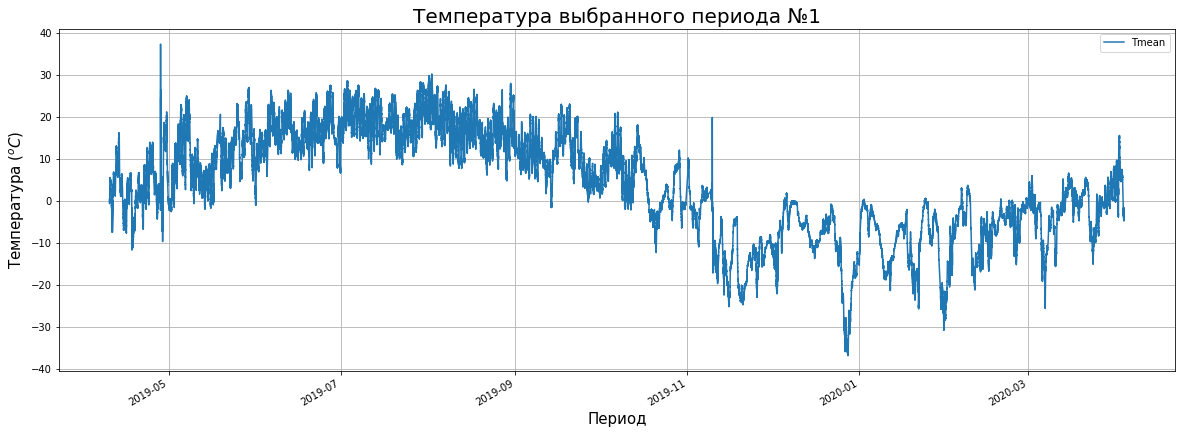

In [7]:
plt.figure()
per_temp2.plot(figsize=[20,7])
#per_temp2.plot(style='k.')
plt.title('Температура выбранного периода №1', fontsize=20)
plt.grid(True)
plt.ylabel('Температура ($^oC$)',fontsize=15)
plt.xlabel('Период',fontsize=15)
plt.legend()

## Среднесуточная

In [8]:
means80 = data80.groupby(pd.Grouper(freq='D')).mean()  # ПЕРИОД
means80

,AffinityIndex,H,Tmean,WmeanH,WindDirectionH(Â°),WminH,WmaxH,WmeanV,AtmosphericPressure,RelativeHumidity,TdewPoint(Â°C),WaterVaporElasticity,AbsolutusHumidity,DensityofAir,SpeedofSoundinAir
DateTime,,,,,,,,,,,,,,,
2019-04-10,10,10,0.953653,1.273069,175.509743,0.800223,1.834210,0.189241,761.282958,52.009875,-8.441461,6.824916,5.382396,0.000129,332.427516
2019-04-11,10,10,3.040520,1.204289,205.786745,0.666100,1.844261,0.021256,761.203199,47.807849,-7.993289,7.800772,6.115195,0.000128,333.708321
2019-04-12,10,10,7.867897,1.760139,202.093963,0.888057,2.873858,-0.031353,755.839924,54.268931,-1.337113,10.891800,8.391246,0.000124,336.728244
2019-04-13,10,10,8.263294,1.897878,204.509015,1.106817,2.859390,0.117178,750.478225,64.842552,0.327060,11.594885,8.884660,0.000123,337.006671
2019-04-14,10,10,1.290799,2.152153,187.586875,1.302083,3.208243,0.305035,755.283903,53.964278,-7.727153,6.967614,5.490102,0.000127,332.647250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-05,10,10,5.910915,1.382308,128.875052,0.516985,2.588413,0.051088,761.367866,35.570464,-10.094407,9.613756,7.451132,0.000126,335.397200
2020-04-06,10,10,6.763097,1.312222,191.237986,0.655292,2.161146,-0.035493,753.501326,53.385903,-4.562569,10.129193,7.831713,0.000124,336.020139
2020-04-07,10,10,8.445708,1.840271,165.661736,0.833375,3.220174,-0.032854,752.207722,59.937708,0.510437,11.242318,8.650620,0.000123,337.125944


In [9]:
#pd.set_option('display.max_rows', 500)

per_temp80 = means80['Tmean']  #24     48 ТЕМПЕРАТУРА

per_temp80

DateTime
2019-04-10    0.953653
2019-04-11    3.040520
2019-04-12    7.867897
2019-04-13    8.263294
2019-04-14    1.290799
                ...   
2020-04-05    5.910915
2020-04-06    6.763097
2020-04-07    8.445708
2020-04-08    3.903807
2020-04-09    0.957469
Freq: D, Name: Tmean, Length: 366, dtype: float64

In [10]:
# Using plotly.express
import plotly.express as px

import pandas as pd

fig = px.line(per_temp80, title='Температура выбранного периода ст. 80')
fig.show()


## Прогноз

In [11]:
ssa = SSAv3(per_temp80) #
[x for x in dir(ssa) if '__' not in x and x[0]!='_']

['SVD',
 'diagonal_averaging',
 'embed',
 'forecast_recurrent',
 'freq',
 'getcontributions',
 'ts',
 'ts_N',
 'ts_name',
 'ts_v',
 'view_reconstruction',
 'view_s_contributions',
 'view_time_series']

In [12]:
K = 400 #+ матрица
seasonality = 12 # подозреваемая сезонность (12) 4 особо не влияет

In [13]:
ssa.embed(embedding_dimension=120, frequency=seasonality, verbose=True) # ИЗМЕНИТЬ ОБЯЗ 120 /40 стандартное
#         размер вложения 120        подозреваемая частота=подозреваемая сезонность


In [14]:
ssa.SVD(verbose=True)


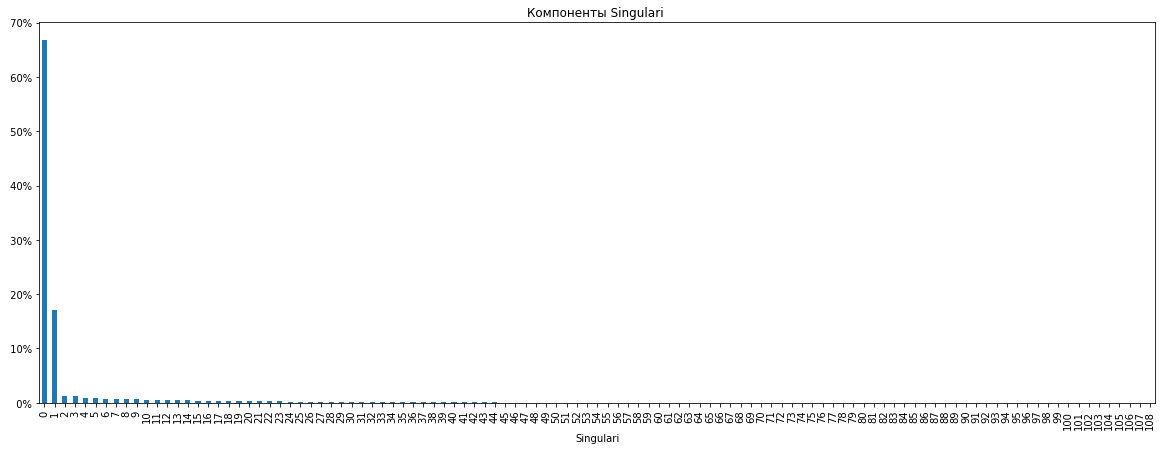

In [15]:
%matplotlib inline 
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20, 7 

ssa.view_s_contributions()


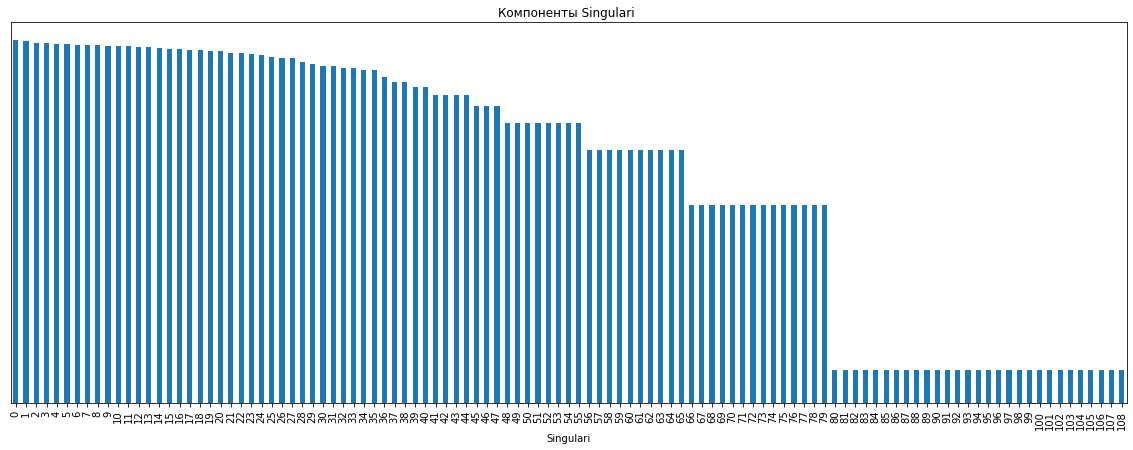

In [16]:
ssa.view_s_contributions(adjust_scale=True)


C:\ProgramData\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\core.py:320: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).

C:\ProgramData\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\core.py:320: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).

C:\ProgramData\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\core.py:320: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To co

C:\ProgramData\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\core.py:320: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).

C:\ProgramData\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\core.py:320: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).

C:\ProgramData\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\core.py:320: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To co

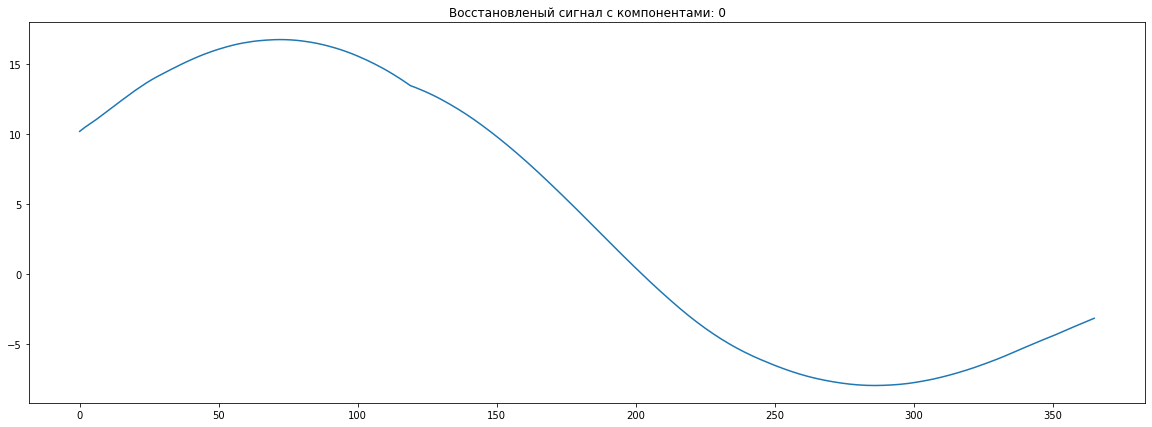

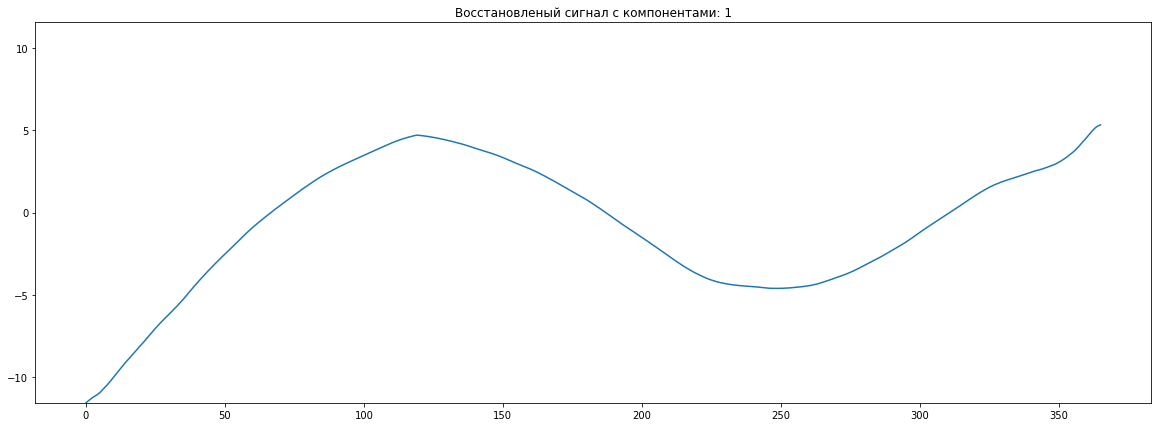

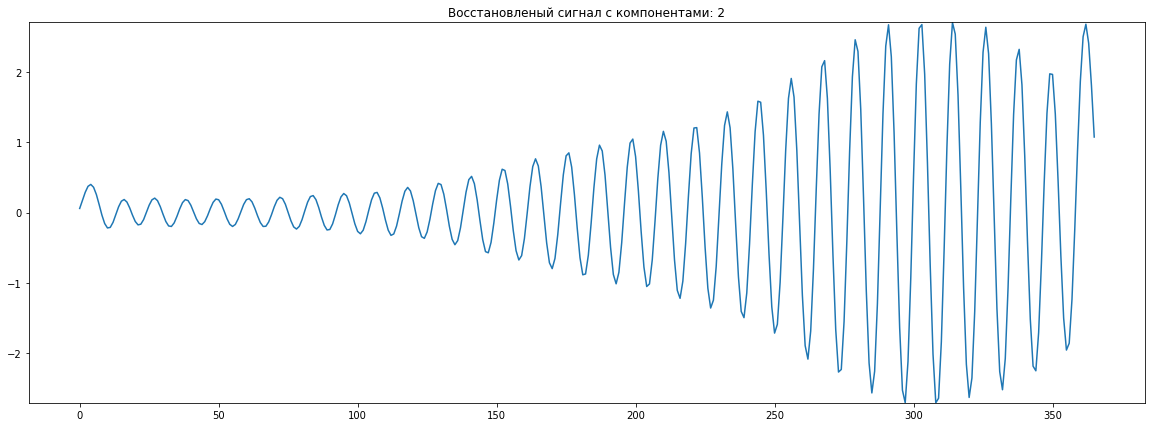

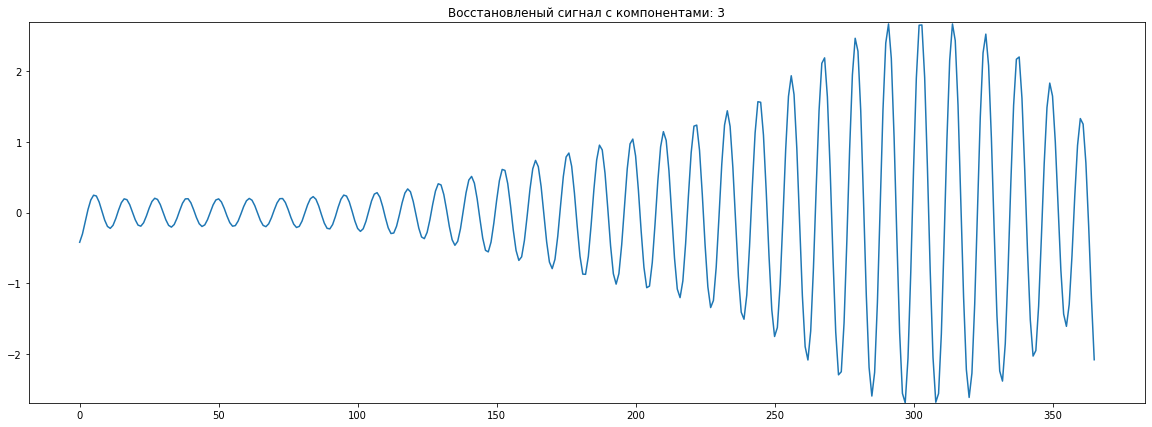

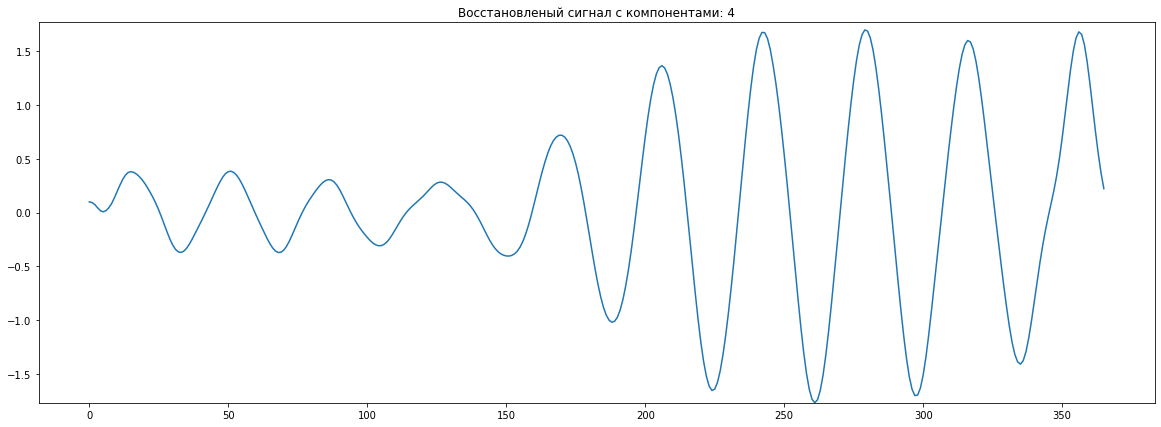

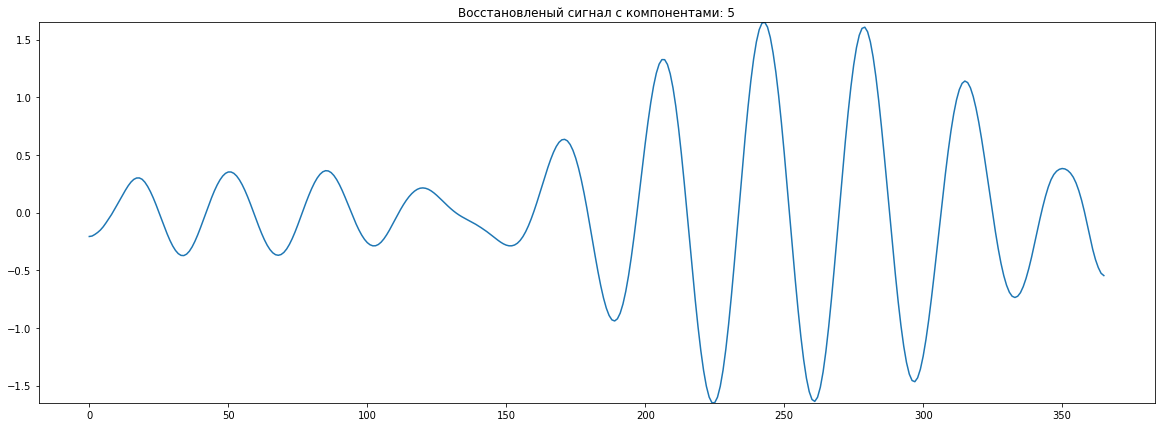

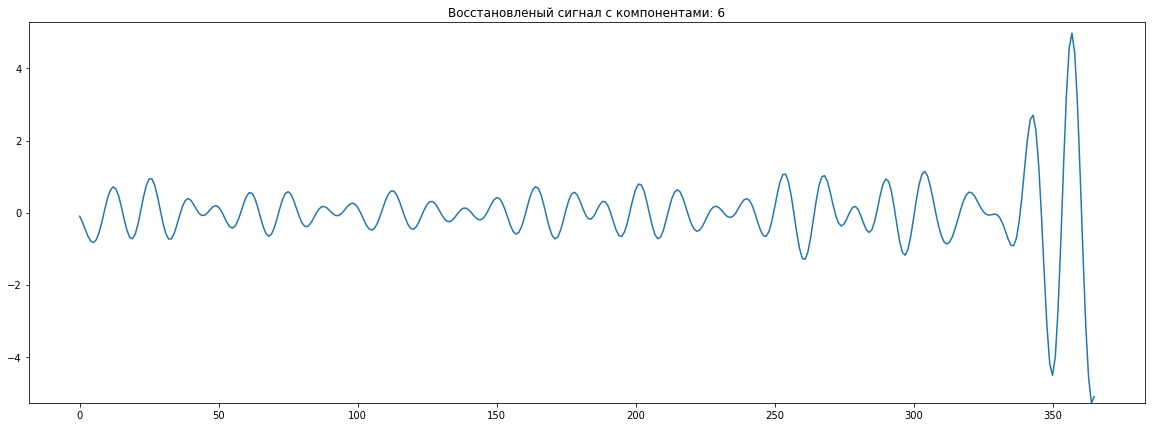

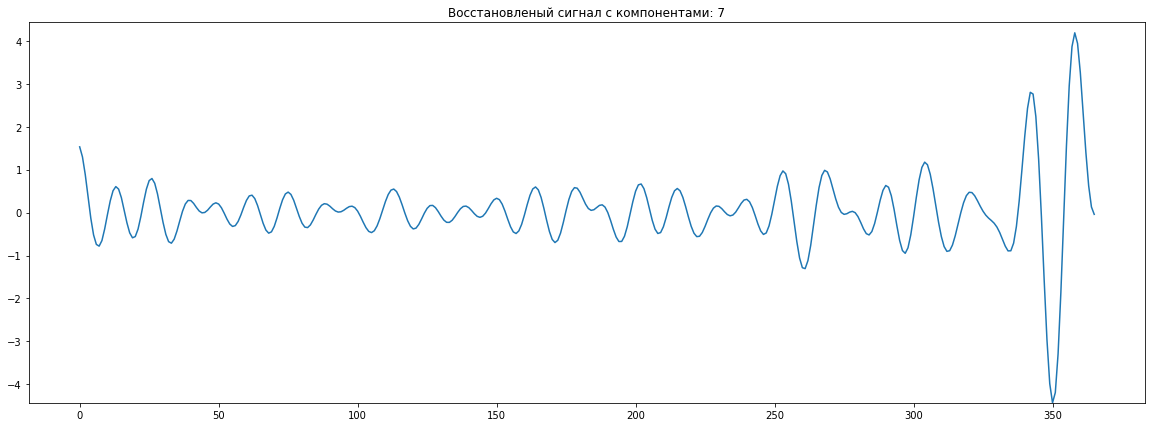

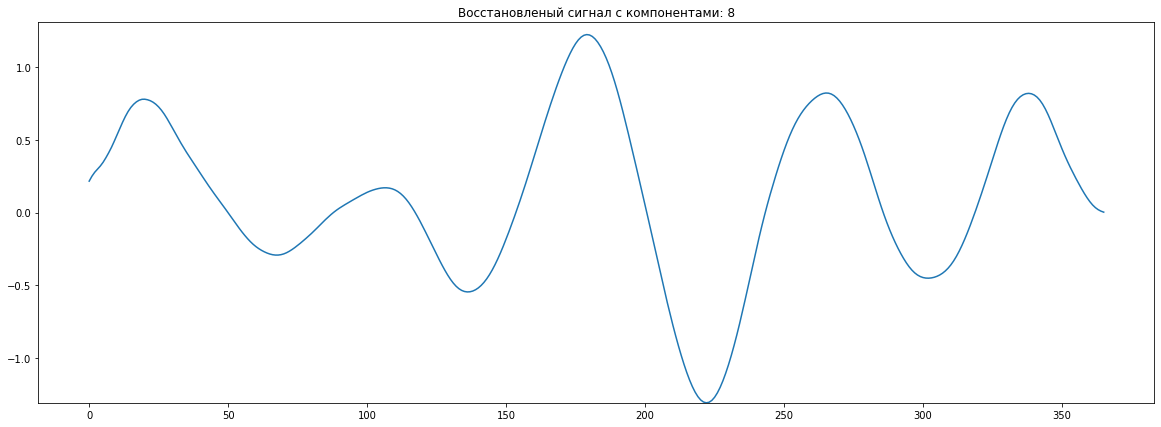

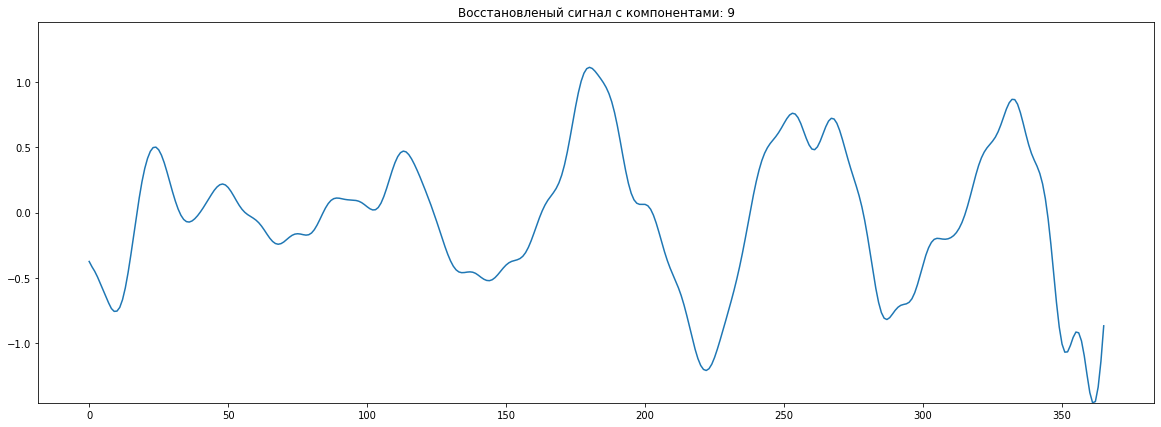

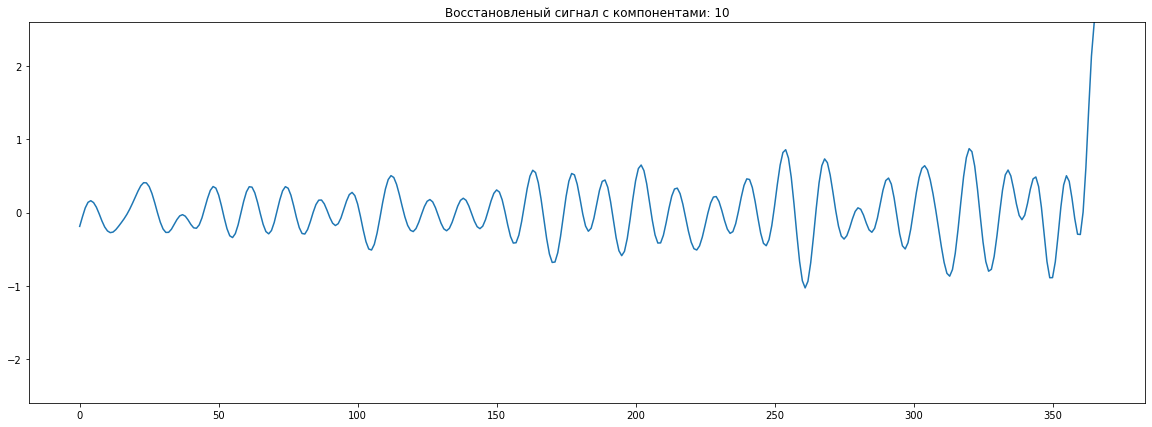

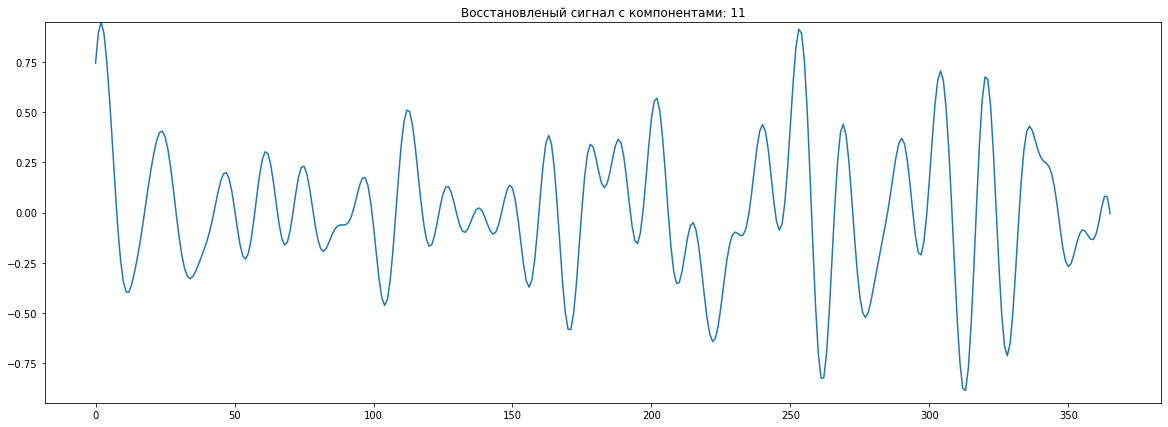

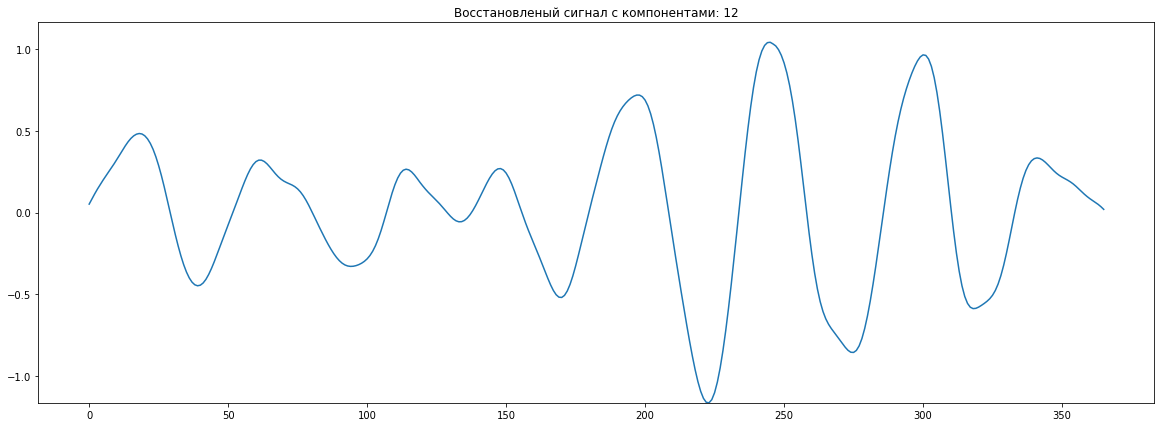

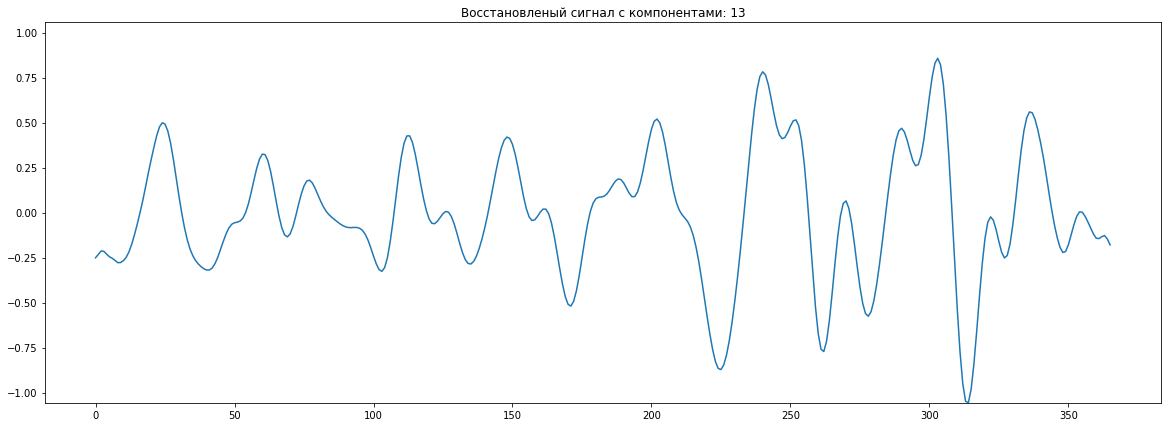

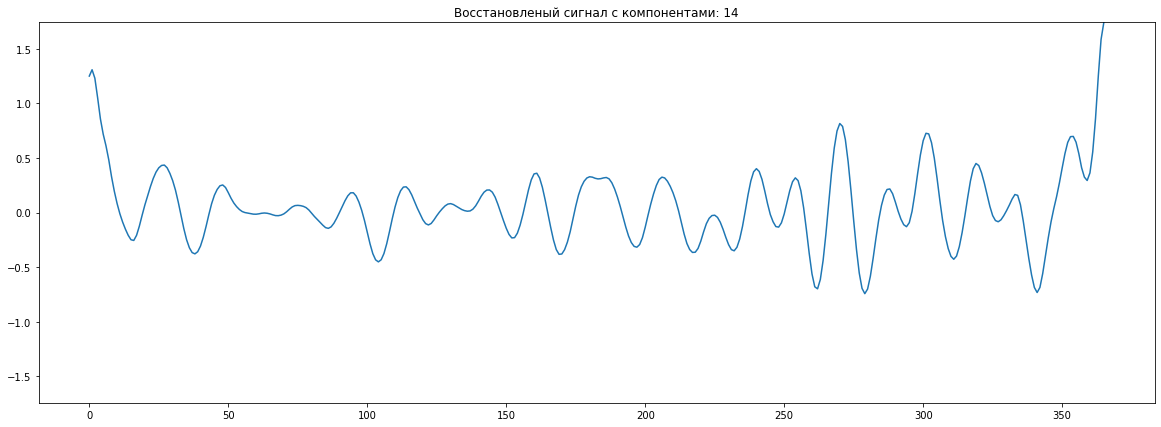

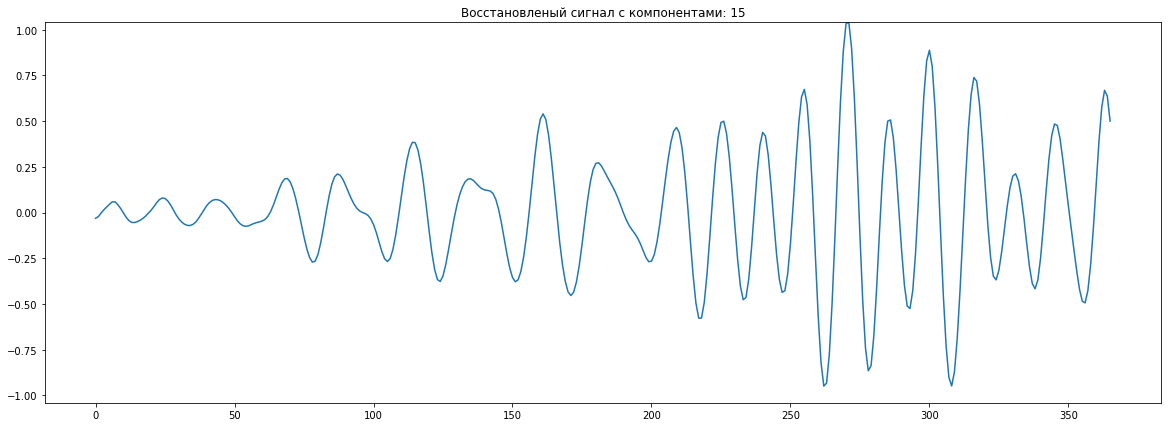

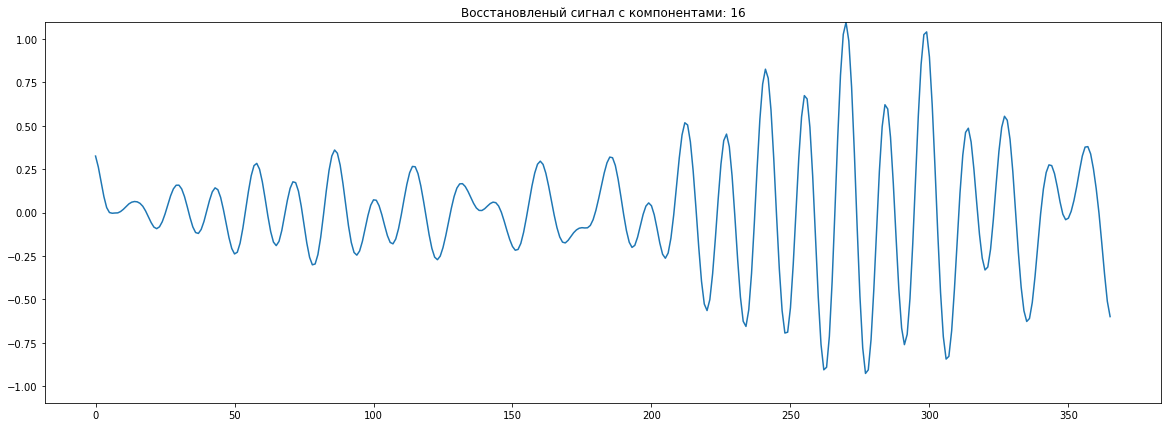

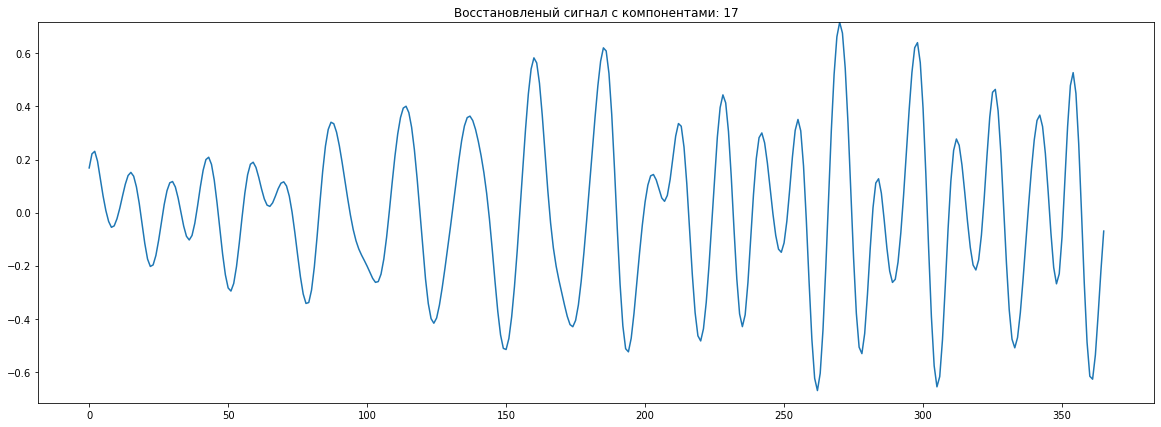

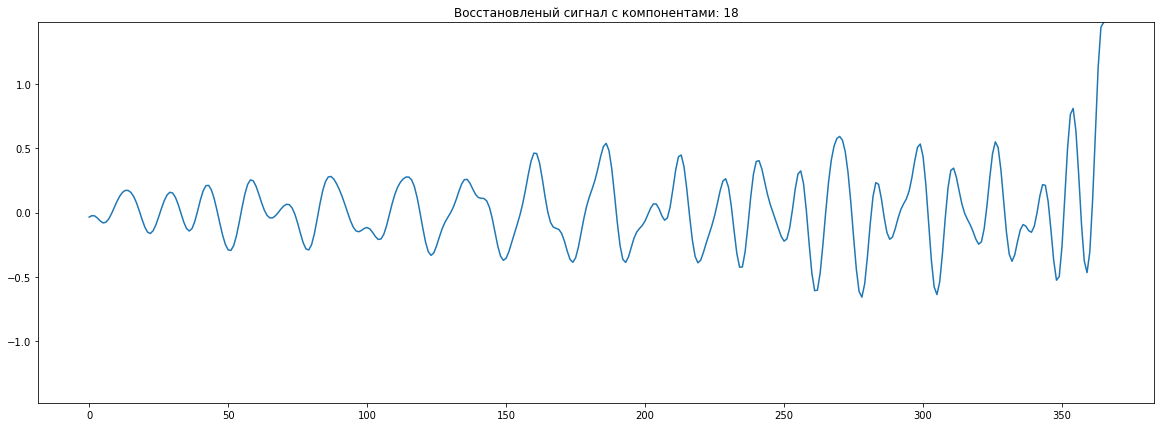

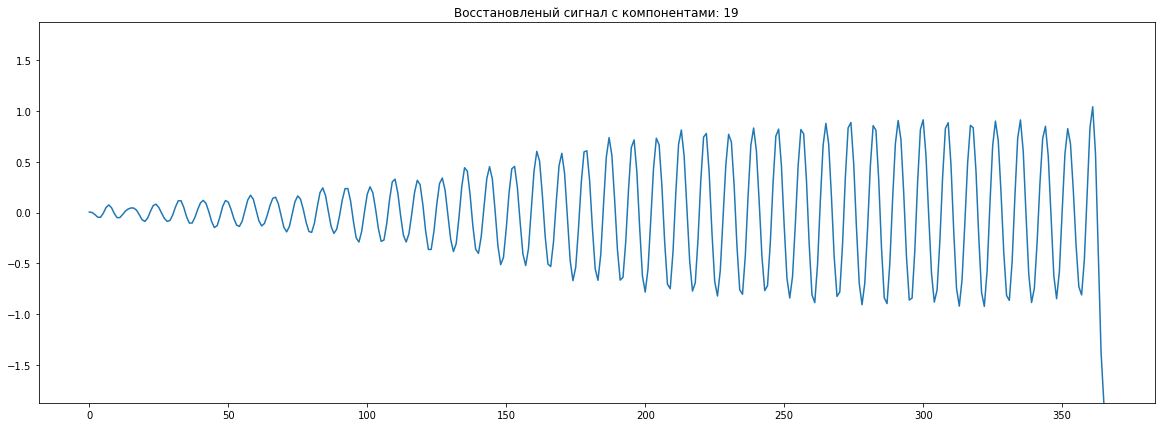

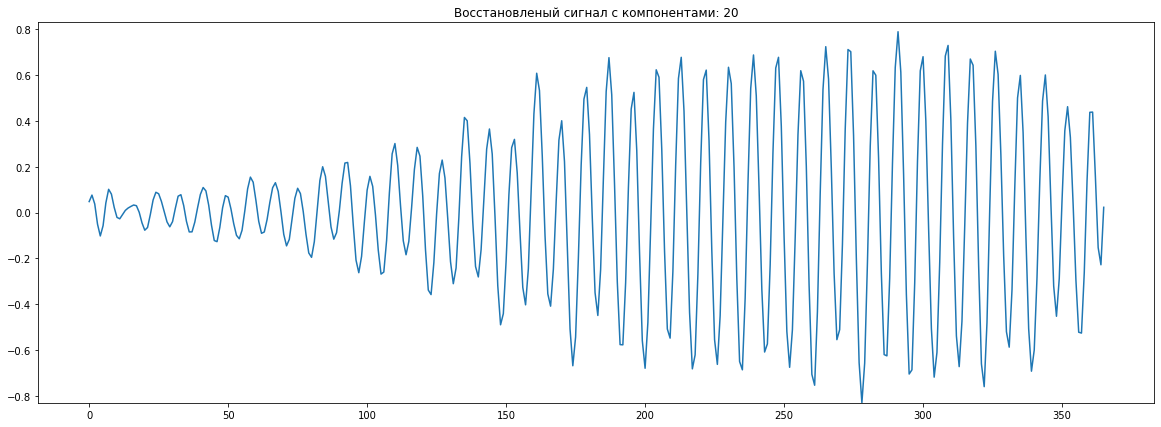

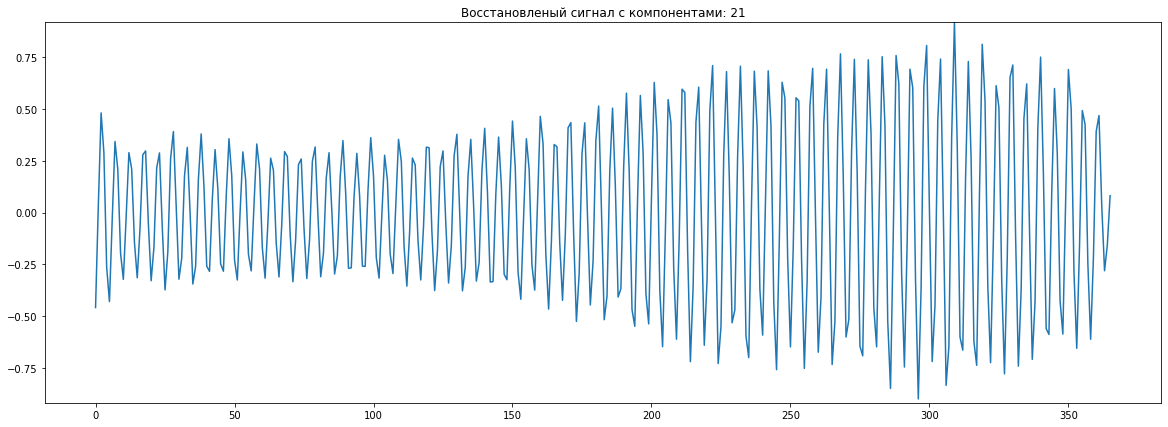

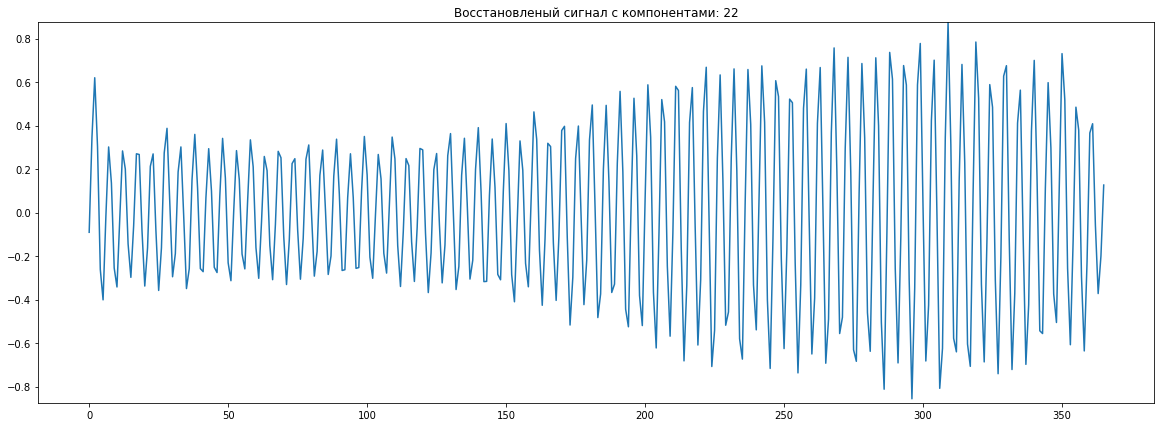

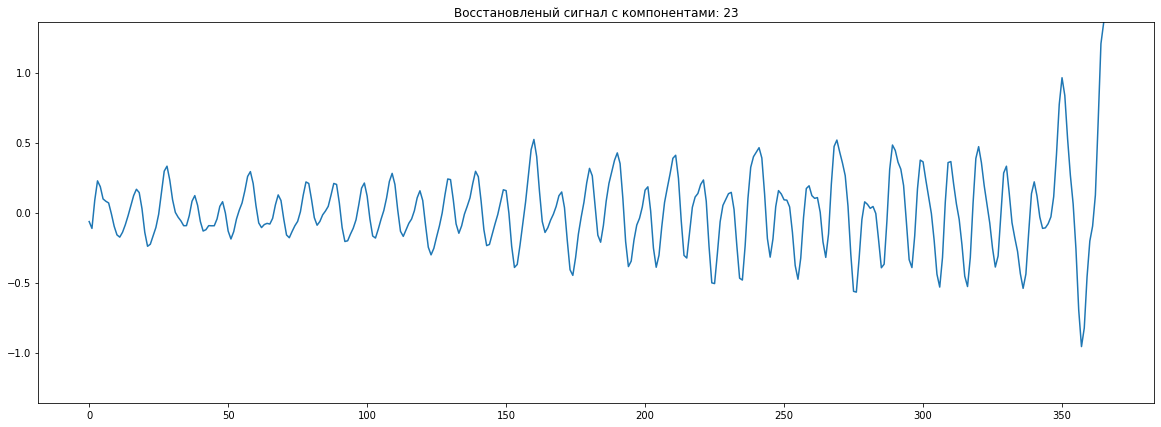

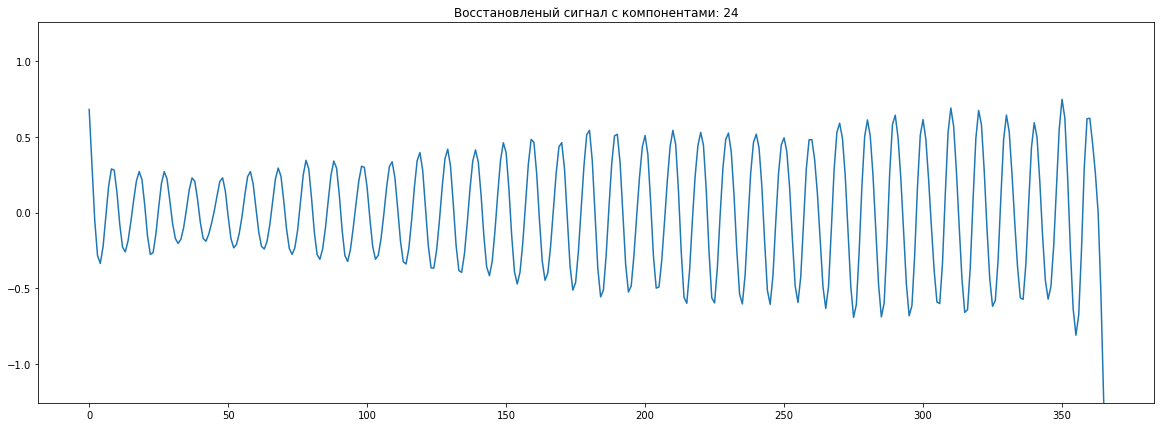

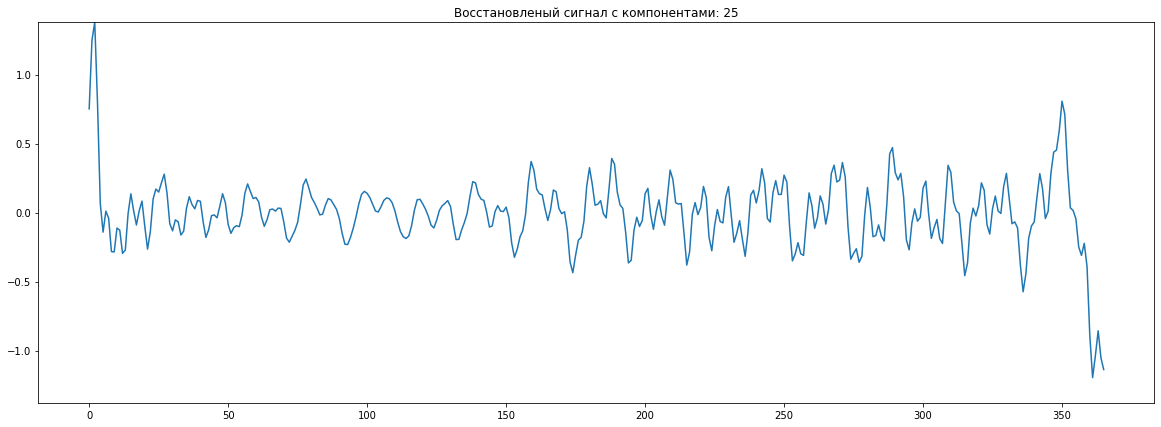

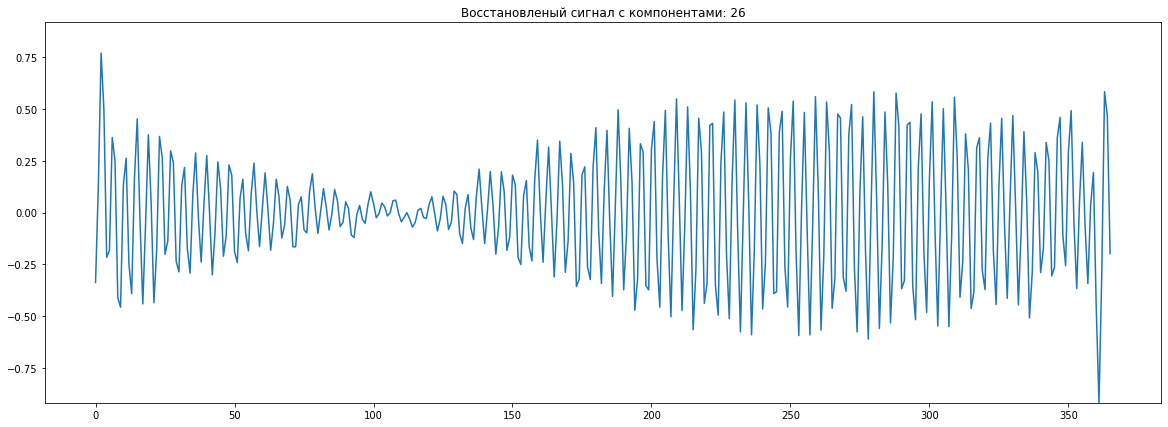

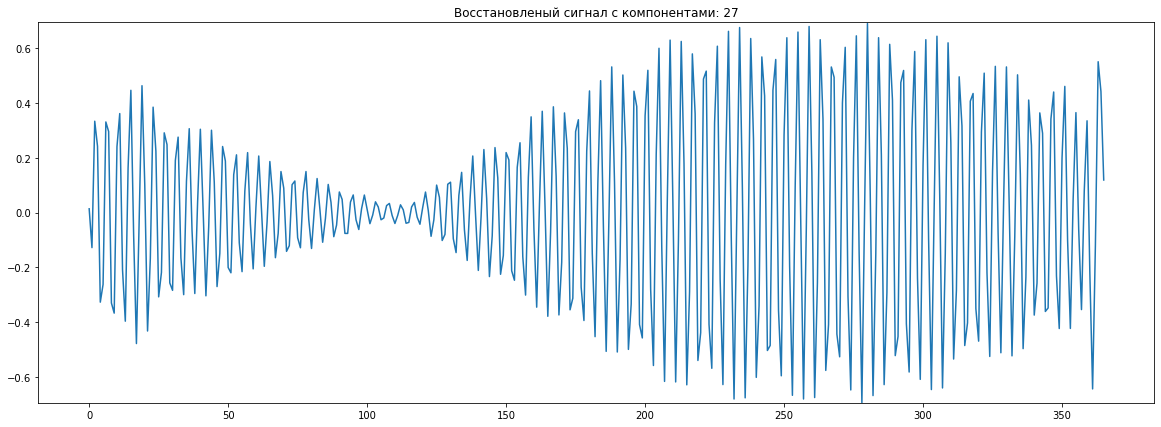

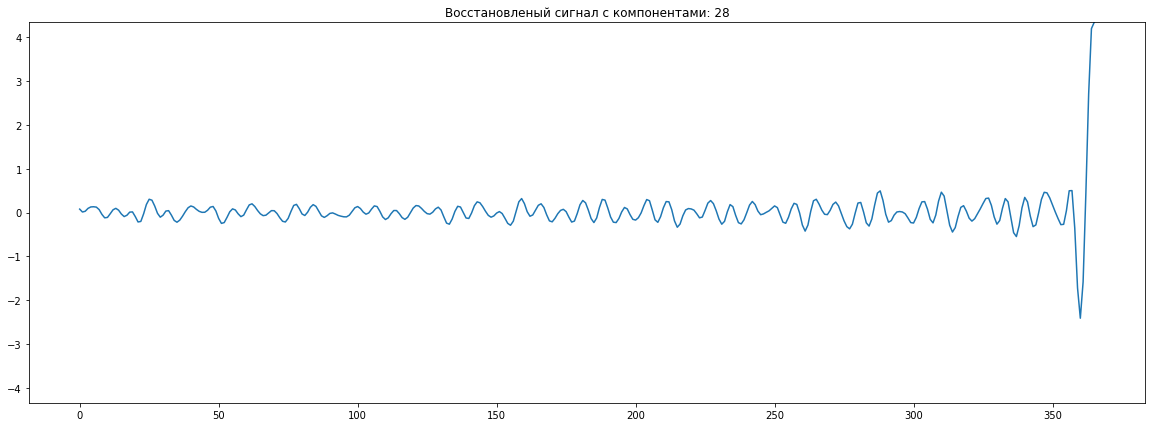

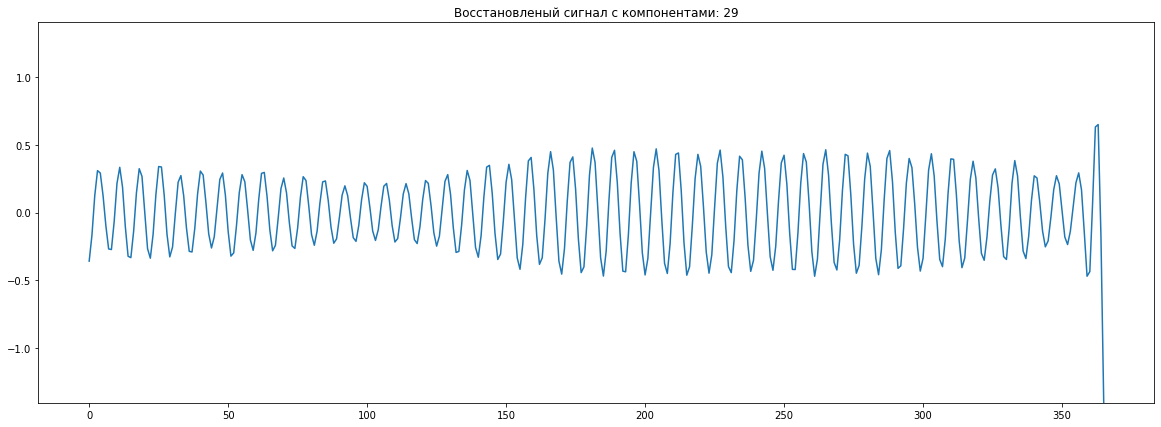

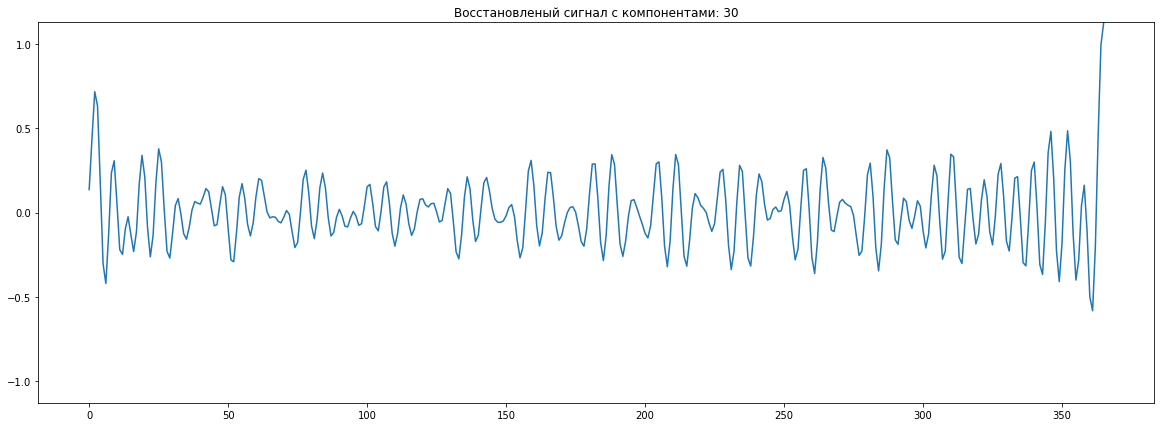

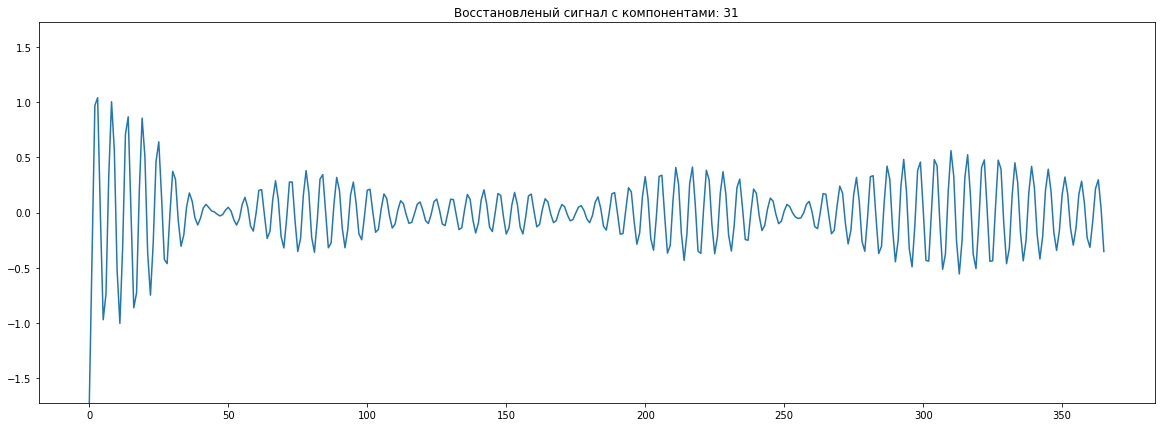

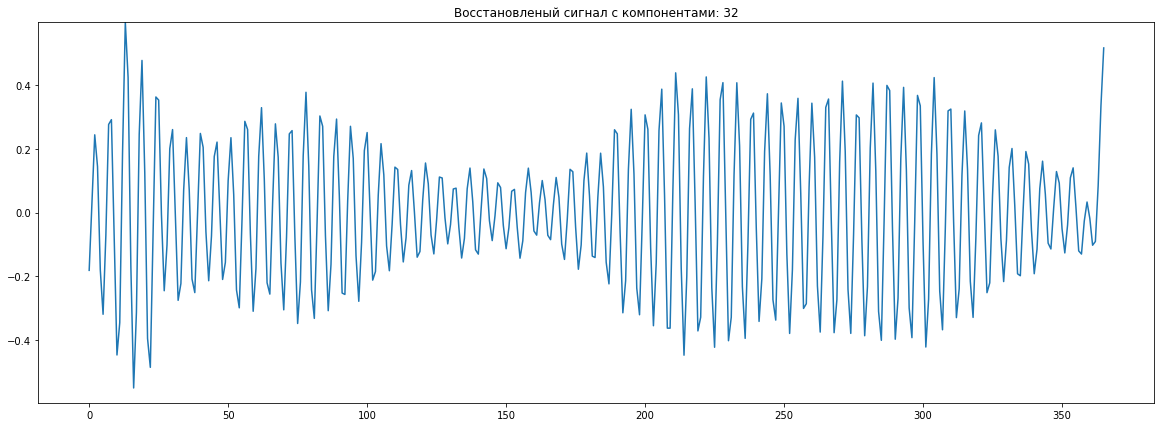

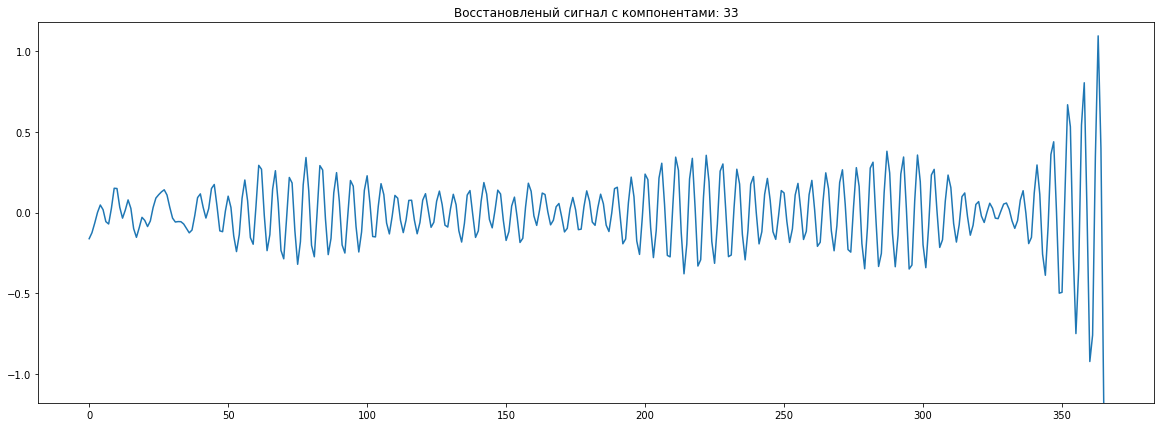

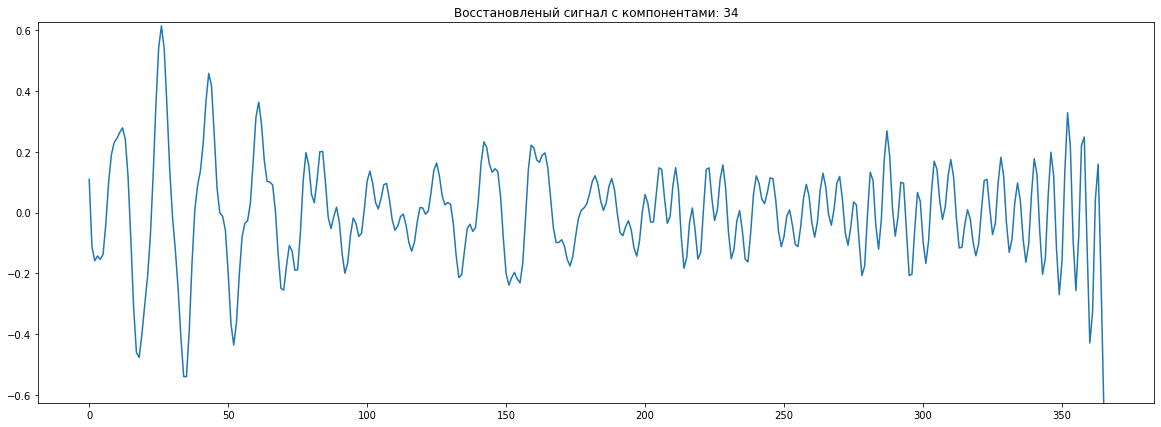

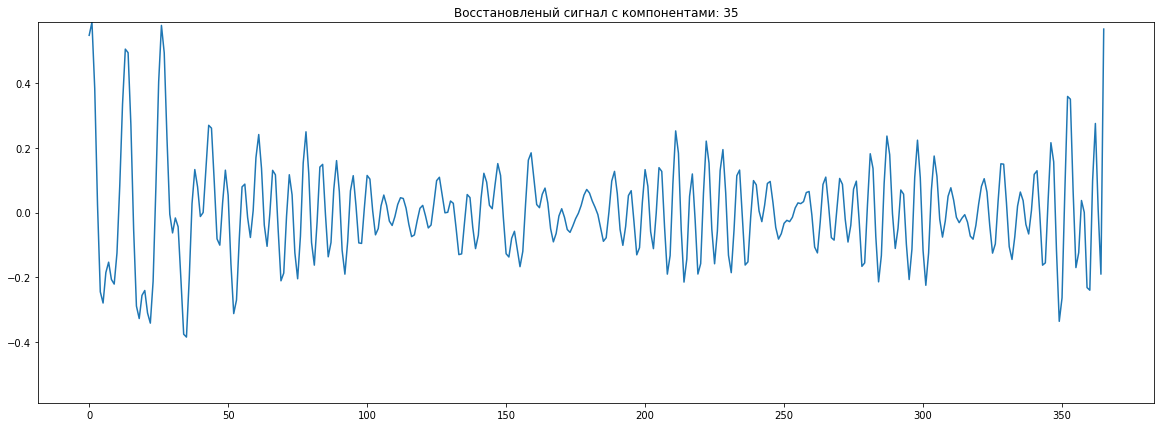

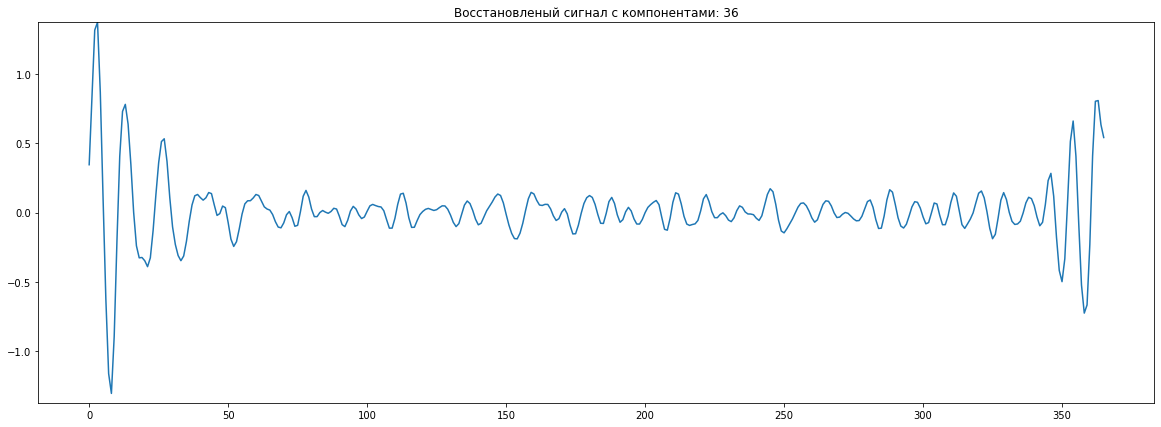

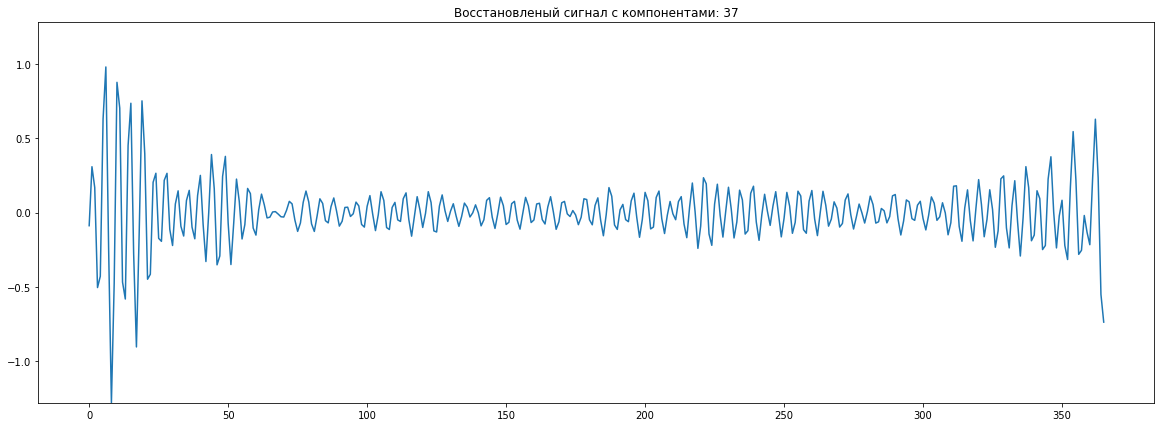

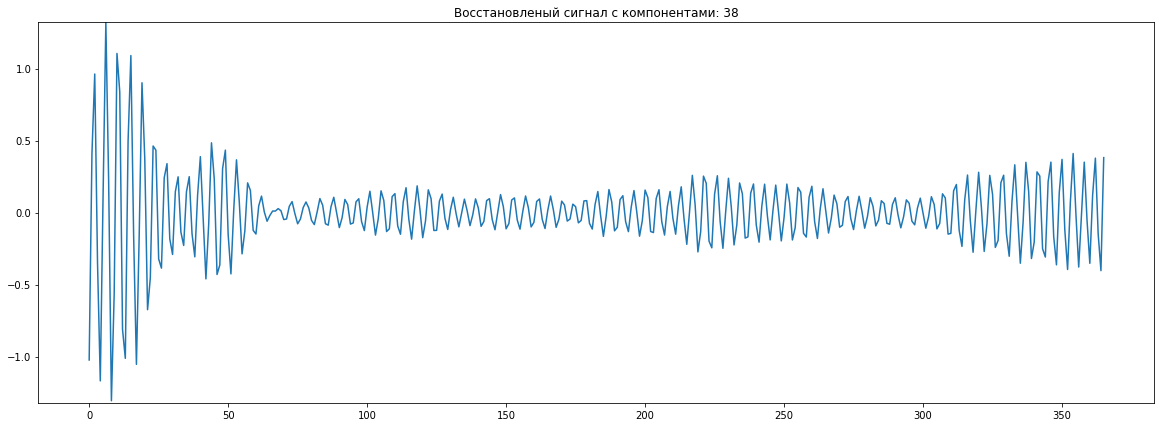

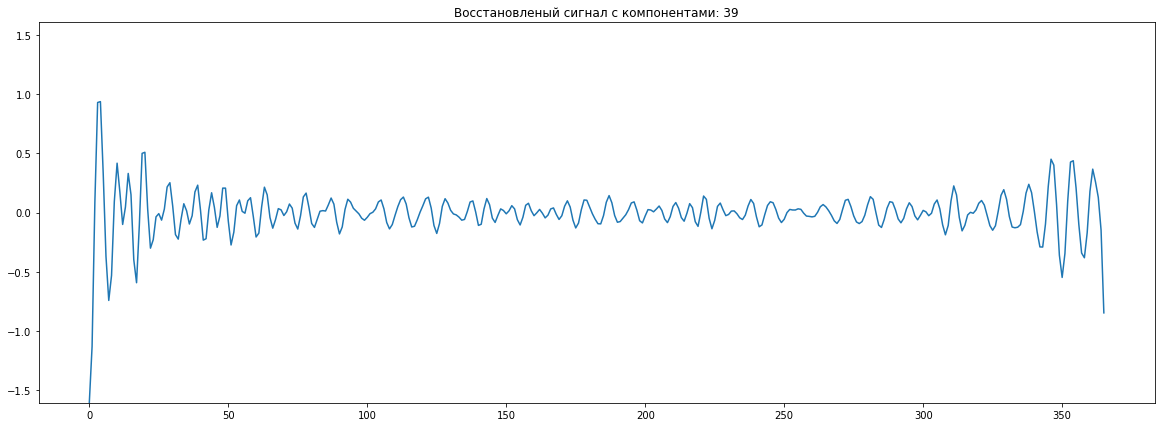

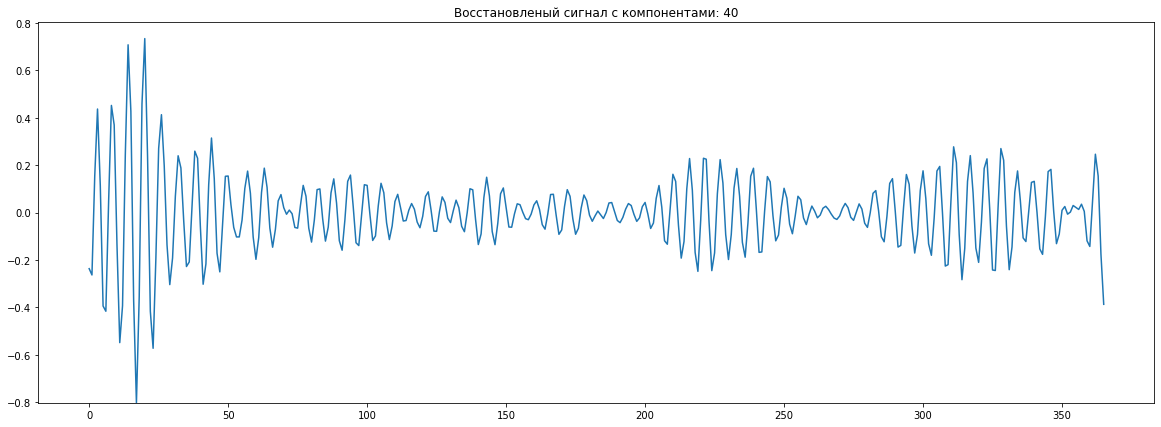

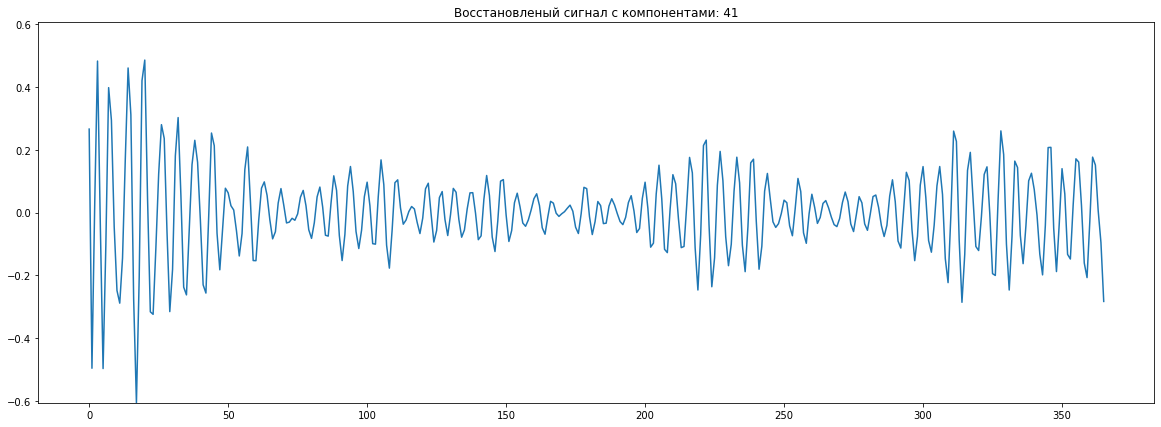

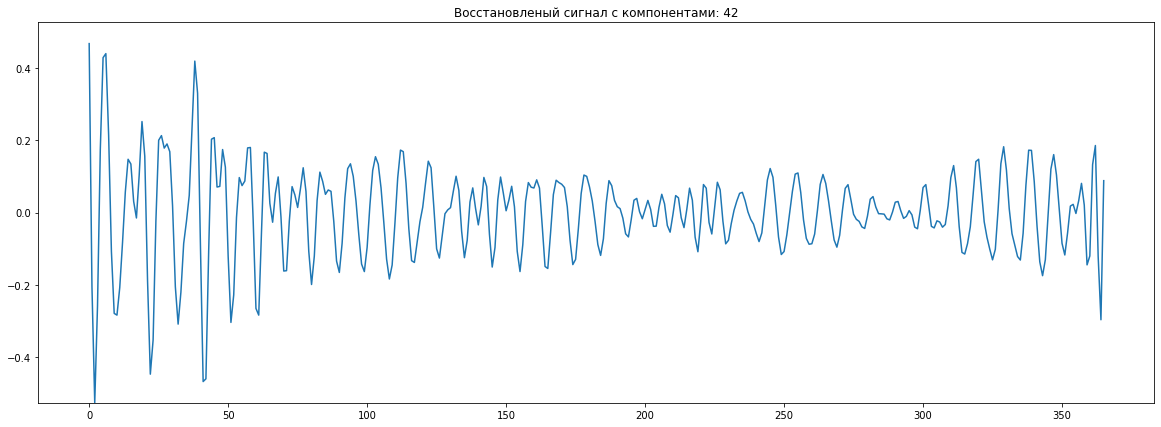

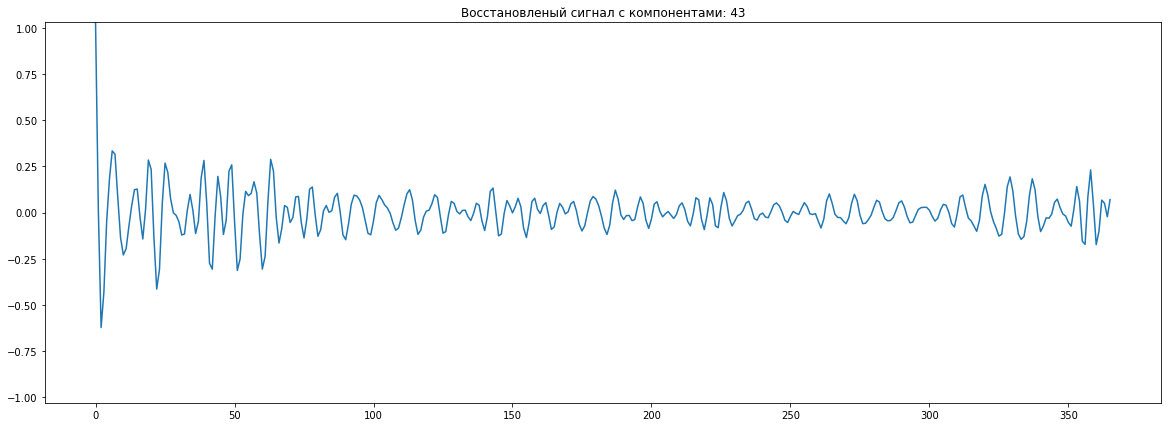

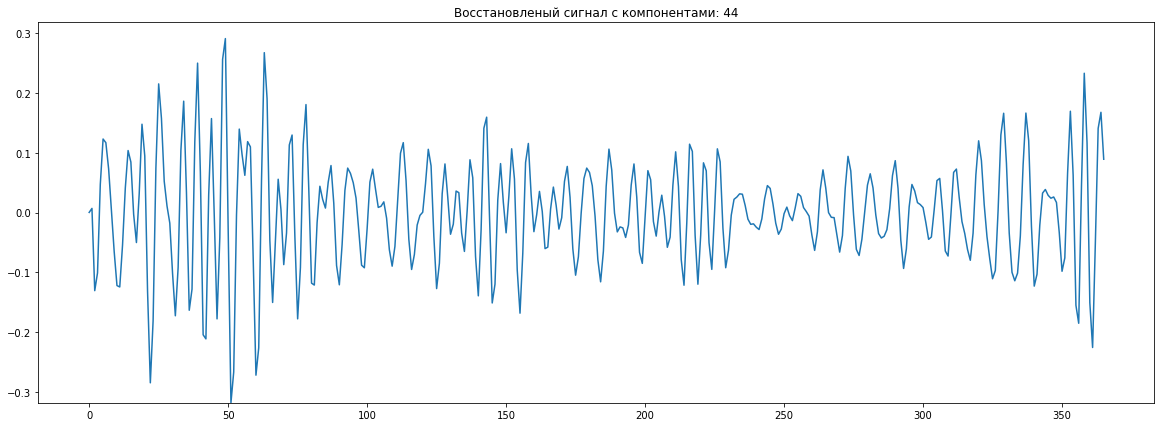

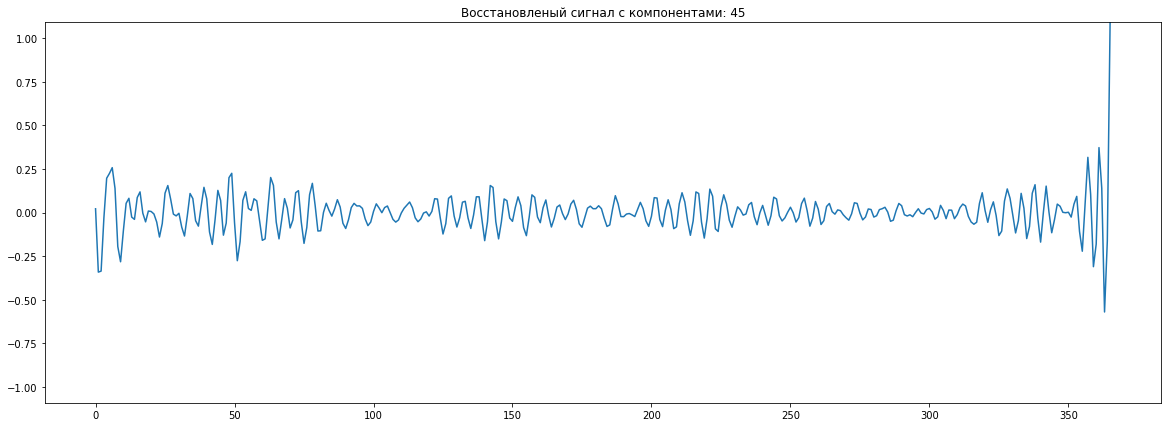

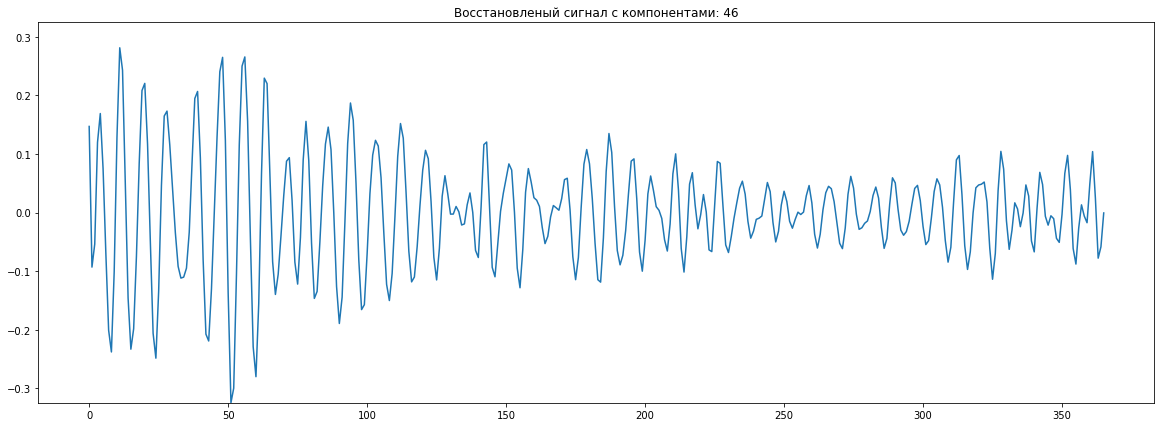

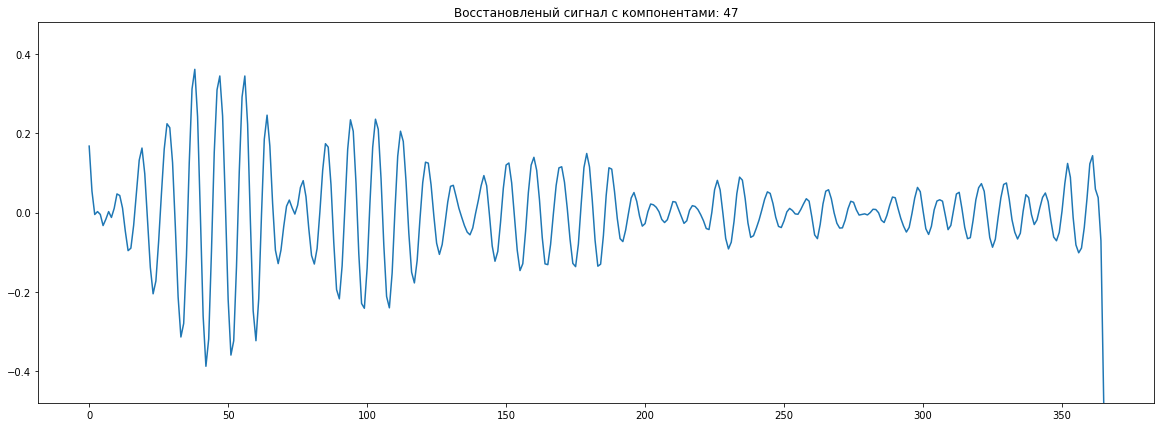

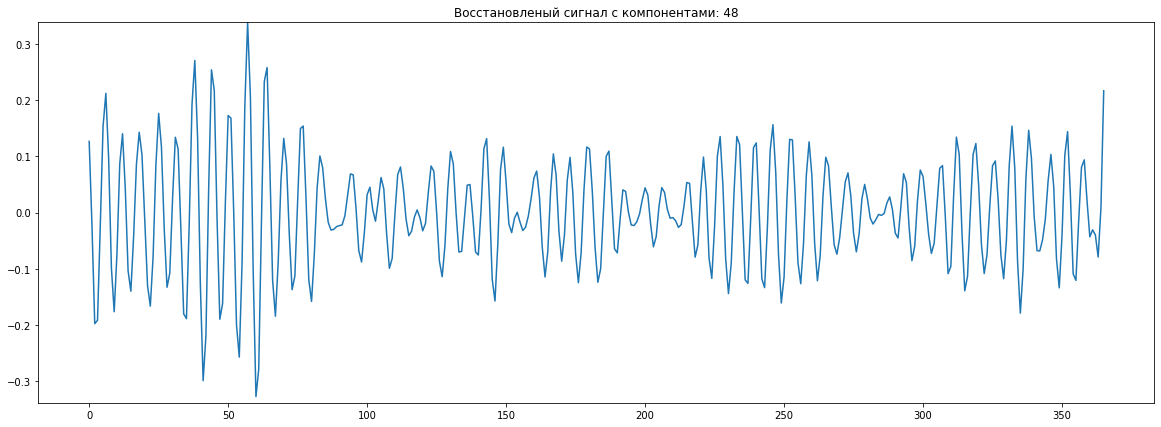

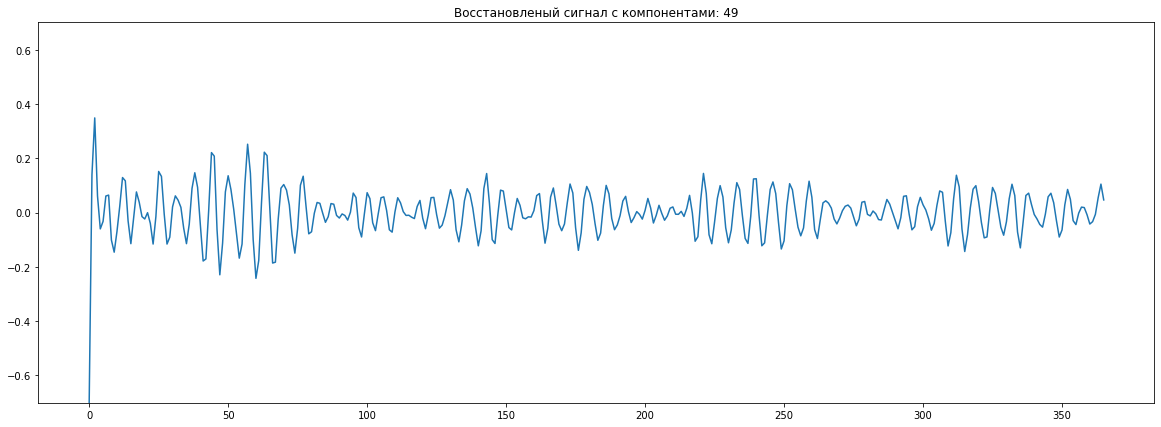

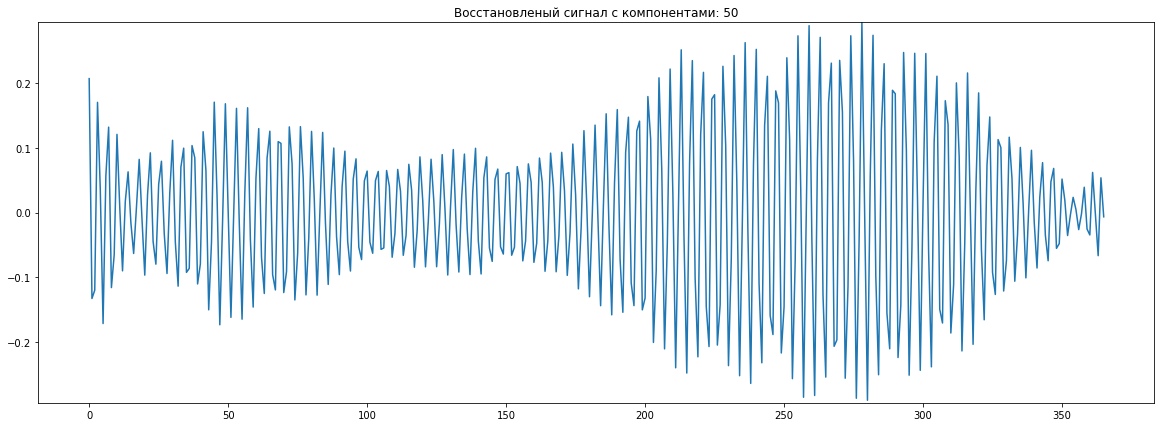

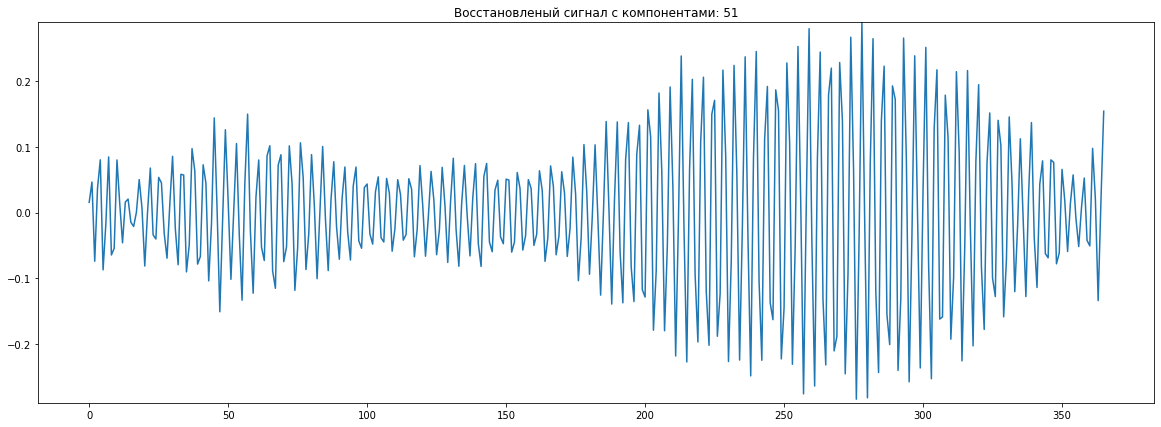

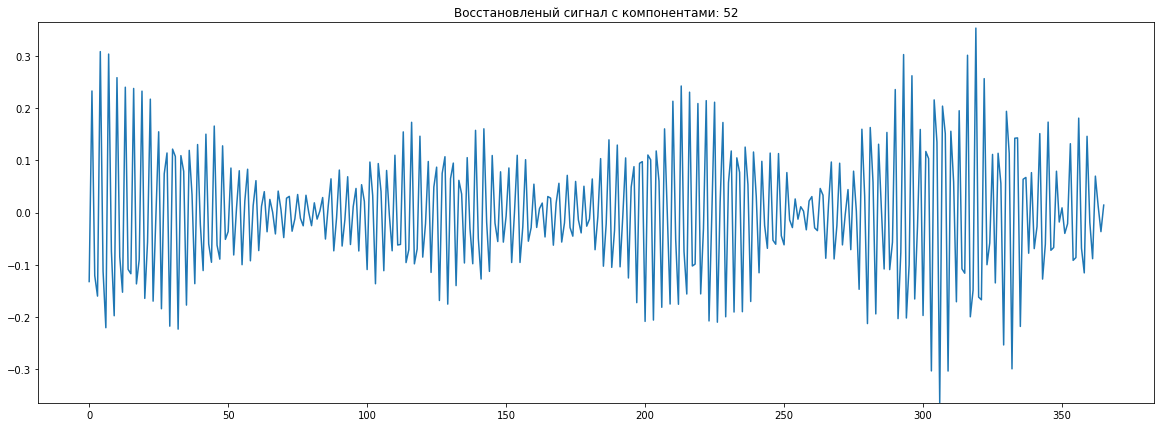

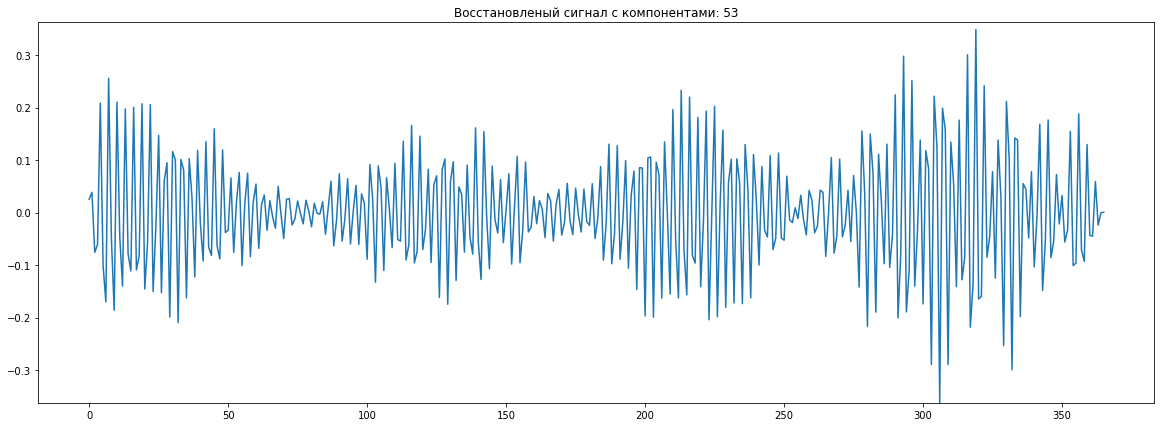

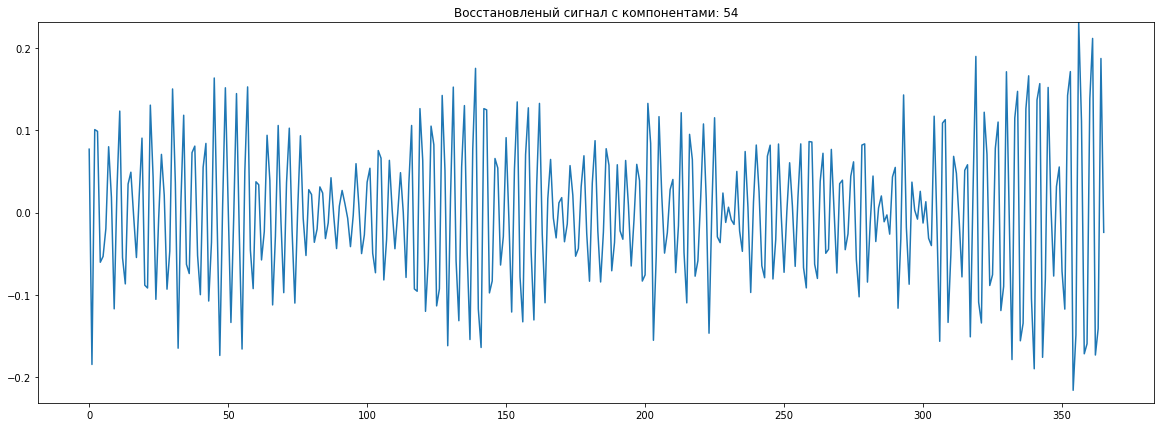

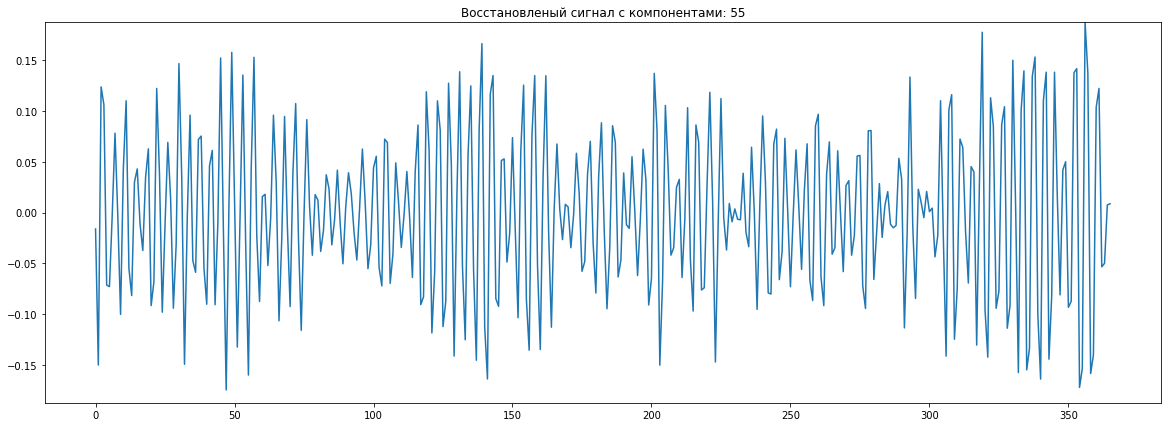

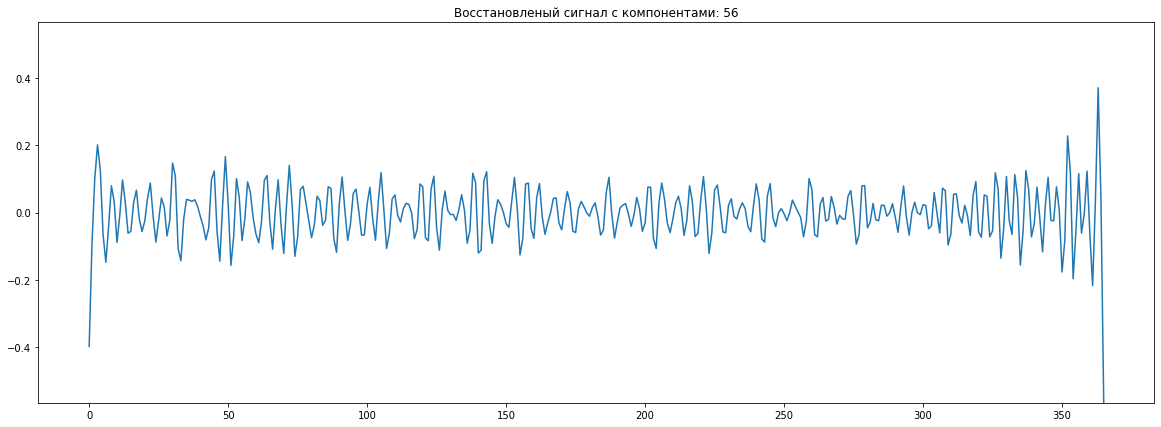

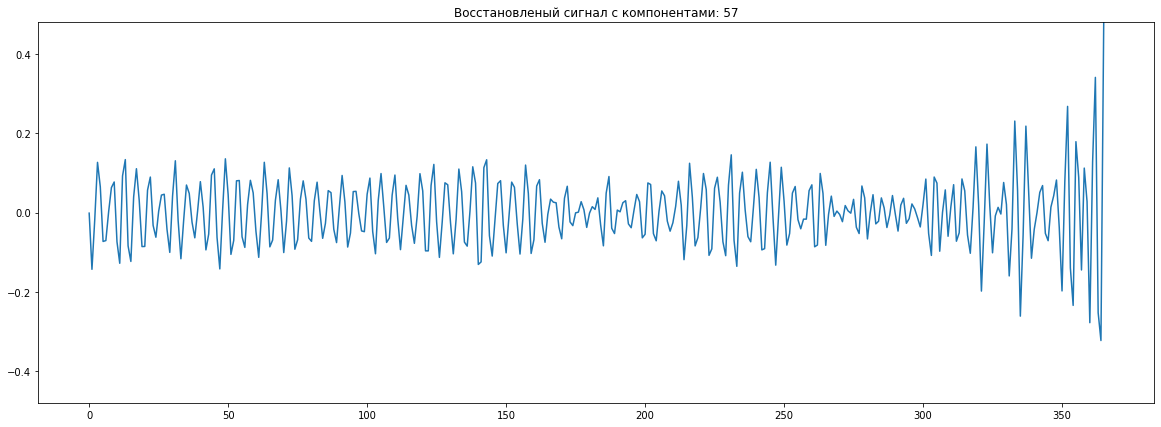

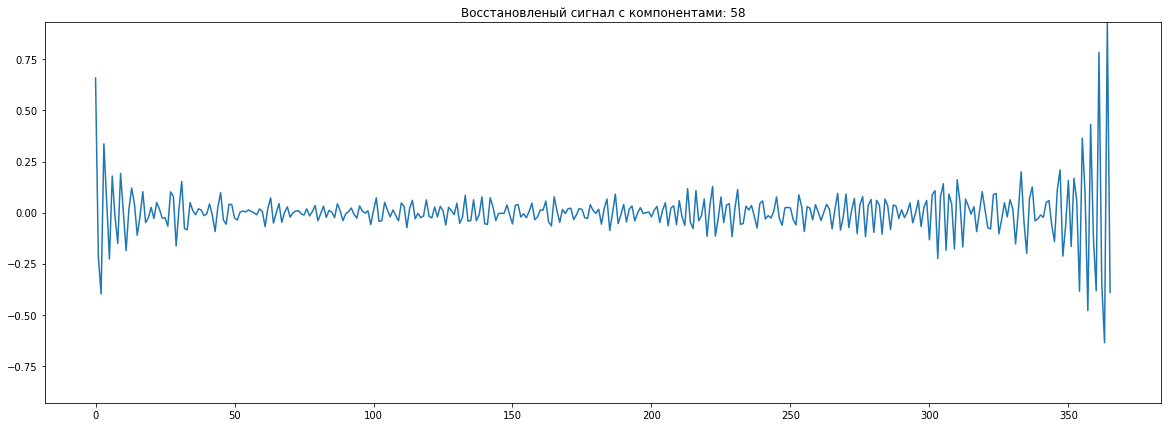

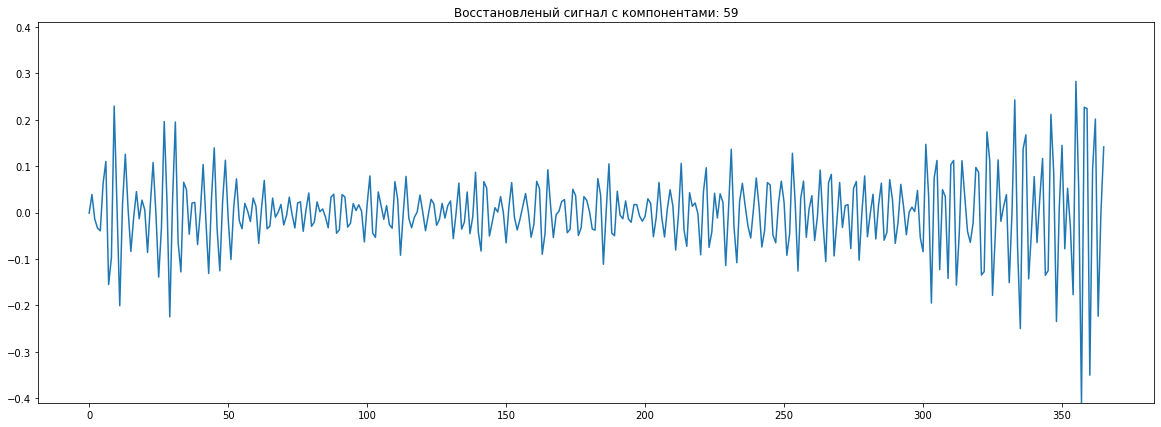

In [17]:
for i in range(60): # количество компонентов \ ИЗМЕНЯЕТСЯ ВОЗМОЖНЫ ОШИБКИ 60
    ssa.view_reconstruction(ssa.Xs[i], names=i, symmetric_plots=i!=0)
# Можно скрыть

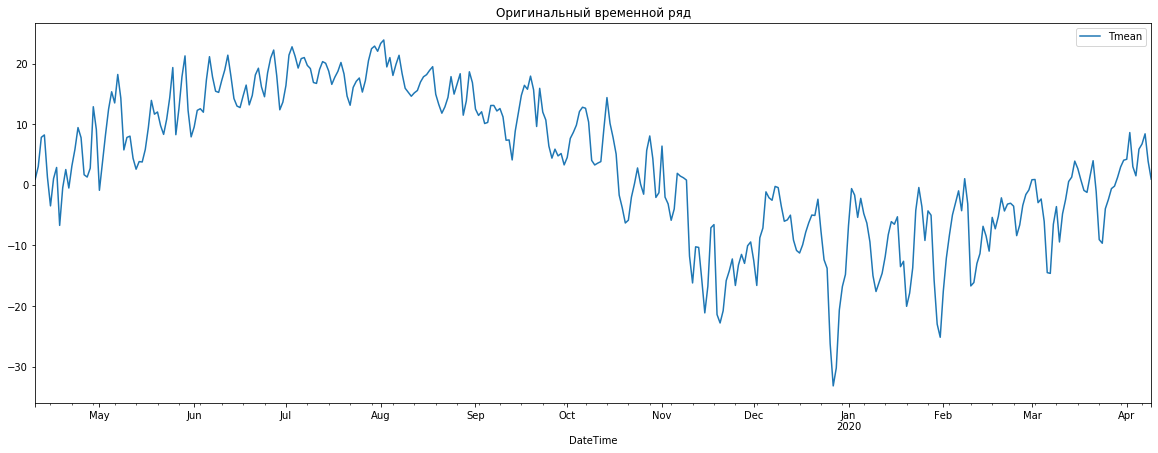

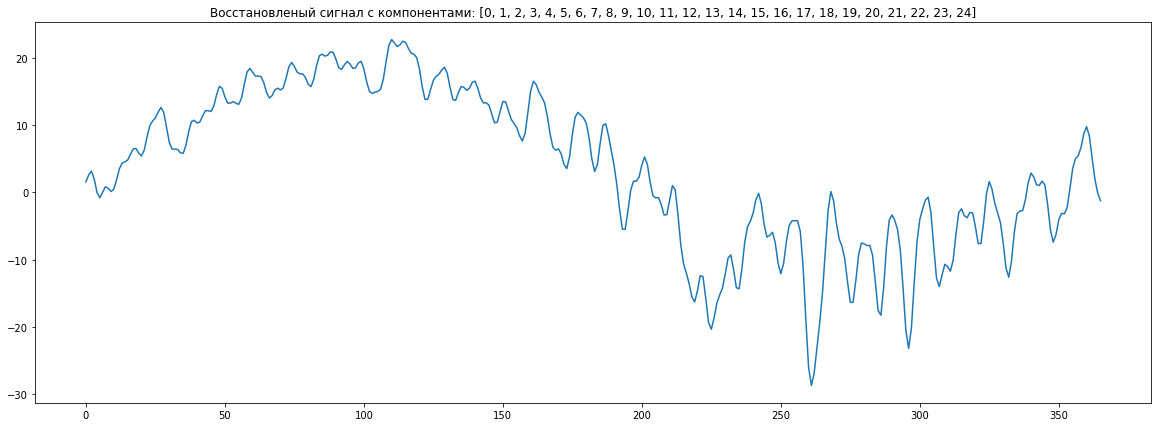

In [18]:
ssa.ts.plot(title='Оригинальный временной ряд'); # оригинальный график для сравнения
streams1 = [i for i in range(25)] # количество компонентов.
reconstructed1 = ssa.view_reconstruction(*[ssa.Xs[i] for i in streams1], names=streams1, return_df=True)


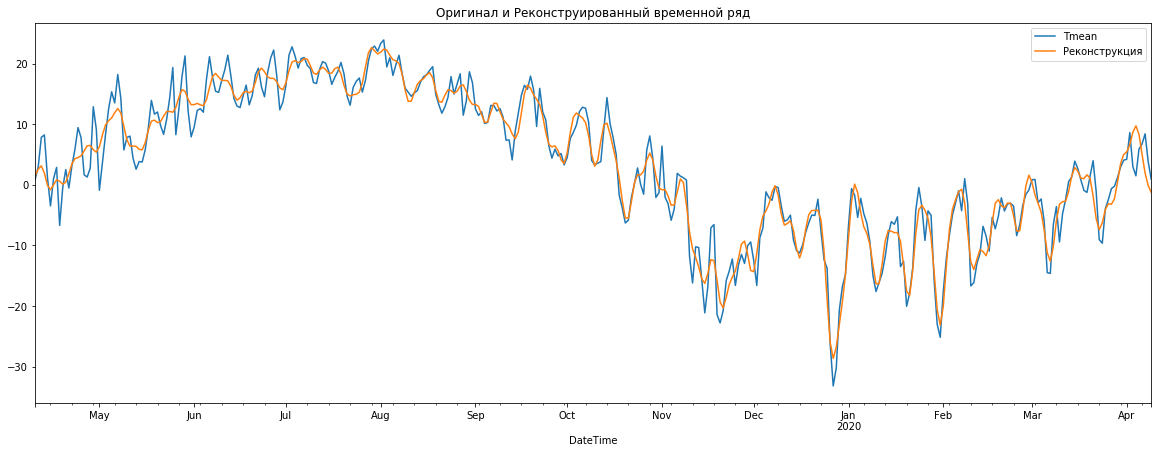

In [19]:
ts_copy1 = ssa.ts.copy()
ts_copy1['Реконструкция'] = reconstructed1.Reconstruction.values
ts_copy1.plot(title='Оригинал и Реконструированный временной ряд');


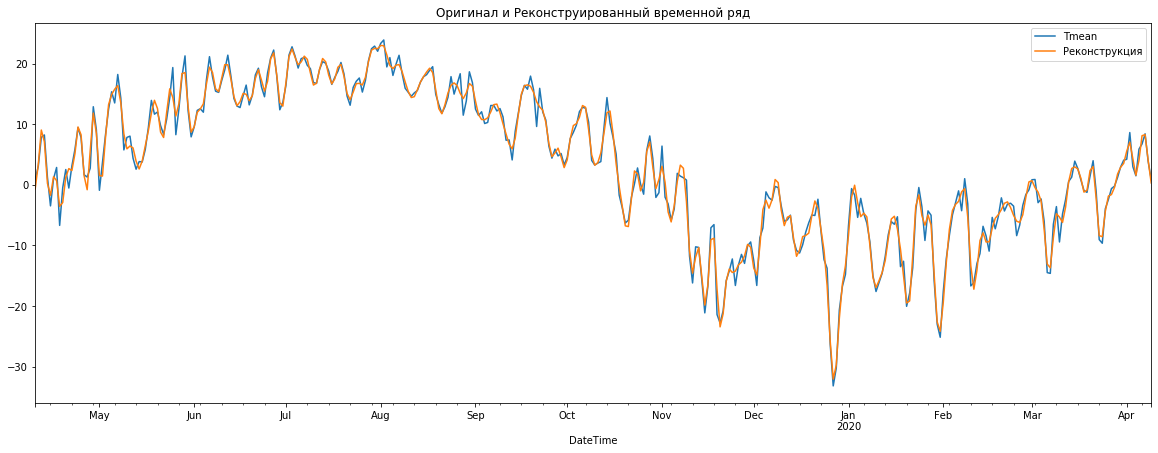

In [20]:
streams2 = [i for i in range(50)] # 10 стандарт. При выборке в 60 ставится 18. Количество выбранных значений для реконструкции
reconstructed2 = ssa.view_reconstruction(*[ssa.Xs[i] for i in streams2], 
                                          names=streams2, return_df=True, plot=False)
ts_copy2 = ssa.ts.copy()
ts_copy2['Реконструкция'] = reconstructed2.Reconstruction.values
ts_copy2.plot(title='Оригинал и Реконструированный временной ряд');


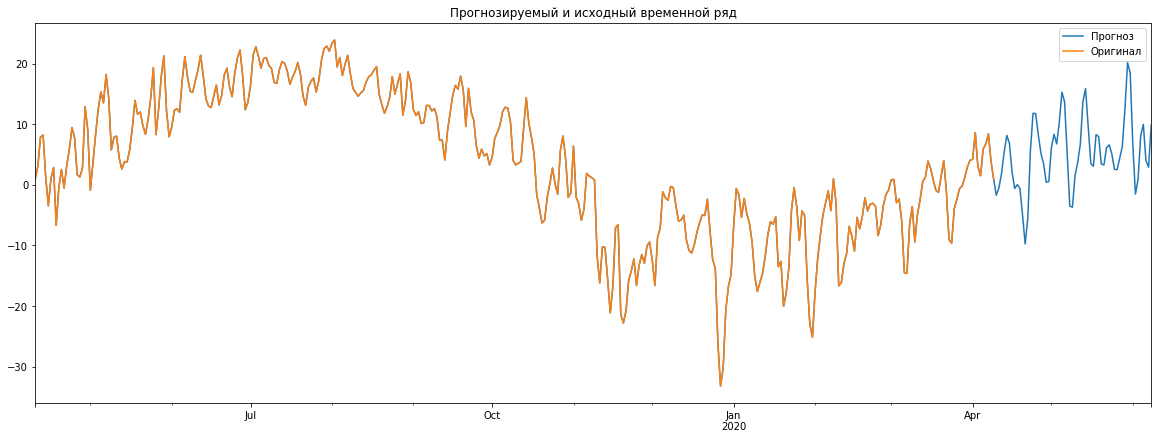

In [21]:
ssa.forecast_recurrent(steps_ahead=60, singular_values=streams2, plot=True) #48 количество прогнозируемых значений (60 дней))
